# Notebook C: Validation & Analysis

Repairs and validates the supply chain built in Notebook B:
entity consolidation, missing edge patches, path traceability,
port assignment comparison, and full output export.

**Reads:** `_pipeline_state_5.pkl` (from Notebook B)  
**Writes:** `_pipeline_state_6.pkl`  
**CSVs output:** `Chile_Supply_Chain_Edges.csv`, `Chile_Export_Destinations.csv`,
`Mine_Optimal_Port_Assignments.csv`, `Mine_Port_Distance_Matrix.csv`,
`Port_Distance_Comparison.csv`, `Port_Comparison_Chart.png`

**Depends on:** Notebook B


In [588]:
import sys
_utils_dir = "/Users/leoss/Desktop/Website-/Portfolio/Website-/projects/Chile/Code"
if _utils_dir not in sys.path:
    sys.path.insert(0, _utils_dir)

from pipeline_utils import *
from pipeline_constants import *  # PRODUCT_TYPE_OVERRIDE, ENTITY_MERGE_MAP, MISSING_S2P, …

state            = load_state(5)
inv, links, comm_col, idle_mines, edges, ports_df = unpack_state(state)
common_cols      = state['common_cols']
smelter_inv_map  = state['smelter_inv_map']
export_df        = state['export_df']
PORT_PRODUCT_MAP = state['PORT_PRODUCT_MAP']
inv_path         = state.get('inv_path',   os.path.join(DIR_INTERMED, 'Chile_Minerals_Inventory.csv'))
links_path       = state.get('links_path', os.path.join(DIR_INTERMED, 'Chile_Mine_Plant_Links.csv'))
cu_total         = state.get('cu_total',   inv['COCHILCO_CU_2024_KMT'].sum())
n_idle_links     = state.get('n_idle_links', 0)

print(f"Loaded state from Notebook B: {len(inv)} inv rows, {len(links)} link rows, {len(edges)} edges")


Loaded state from Notebook B: 461 inv rows, 1109 link rows, 2380 edges


## 5: Cleanup & Validation

Smelter name standardisation, edge fixes, deduplication, and production validation.

In [589]:

# ── 5A. Smelter name standardization ──────────────────────────────────────

section_header("5A. SMELTER NAME STANDARDIZATION")

renamed_count = 0
for canonical, inv_name in SMELTER_NAME_MAP.items():
    exists = inv["FACILITY_NAME"].eq(inv_name).any()
    print(f"  {canonical:<35} -> {inv_name:<55} {'OK' if exists else 'NOT FOUND'}")
    if canonical != inv_name:
        for col in ["FROM_NAME", "TO_NAME"]:
            mask = edges[col] == canonical
            if mask.any():
                edges.loc[mask, col] = inv_name
                renamed_count += mask.sum()
print(f"\nTotal renames: {renamed_count}")

# Handle Las Ventanas / Ventanas ambiguity
las_v   = inv[inv["FACILITY_NAME"].str.contains("Las Ventanas", case=False, na=False)]
v_plain = inv[inv["FACILITY_NAME"].str.contains("Ventanas refinery", case=False, na=False) &
              ~inv["FACILITY_NAME"].str.contains("Las Ventanas", case=False, na=False)]
if len(las_v) > 0 and len(v_plain) > 0:
    print(f"\n  Note: Both '{las_v.iloc[0]['FACILITY_NAME']}' AND '{v_plain.iloc[0]['FACILITY_NAME']}' exist.")

# ── 5A.2 Entity consolidation for duplicate smelter entries ───────────────
#
# Several smelters appear multiple times in the inventory under slightly
# different names or as commodity-specific rows for the same physical
# facility. Edges referencing the variant names need to be remapped to
# the canonical name so that upstream and downstream connect properly.
#
# Affected facilities:
#   "Ventanas refinery and smelter" (4 rows, idx 456-459, Gold/Se/Ag/H2SO4)
#       -> canonical: "Las Ventanas refinery and smelter" (idx 340, Copper)
#   "Chagres smelter" (idx 283, Sulfuric Acid, fully disconnected)
#       -> canonical: "Chagres smelter (anodes and blister)" (idx 284, Copper)

section_header("5A.2: SMELTER ENTITY CONSOLIDATION")

# ENTITY_MERGE_MAP is defined in pipeline_constants.py (imported above).
# Do NOT redefine here — edit pipeline_constants.py to change consolidation rules.

_entity_renames = 0
for variant, canonical in ENTITY_MERGE_MAP.items():
    # Verify canonical exists in inventory
    if not inv["FACILITY_NAME"].eq(canonical).any():
        print(f"  WARNING: canonical name '{canonical}' not in inventory, skipping")
        continue
    # Remap edges
    for col in ["FROM_NAME", "TO_NAME"]:
        mask = edges[col] == variant
        if mask.any():
            n = mask.sum()
            edges.loc[mask, col] = canonical
            _entity_renames += n
            print(f"  {col}: '{variant}' -> '{canonical}' ({n} edges)")
    # Remap links table
    for col in ["MINE_NAME", "PLANT_NAME"]:
        if col in links.columns:
            mask = links[col] == variant
            if mask.any():
                links.loc[mask, col] = canonical
                print(f"  links.{col}: '{variant}' -> '{canonical}' ({mask.sum()} rows)")

if _entity_renames == 0:
    print("  No variant names found in edges (already consolidated or not present)")
else:
    print(f"\n  Total edge renames: {_entity_renames}")

# ── 5B. Andacollo Oro mine link ────────────────────────────────────────────

section_header("5B. ANDACOLLO ORO MINE")

andacollo = inv[inv["FACILITY_NAME"].str.contains("Andacollo", case=False, na=False)]
for _, row in andacollo.iterrows():
    prod = row.get("COCHILCO_CU_2024_KMT", np.nan)
    prod_str = f"{prod:.1f} kMT" if pd.notna(prod) else ""
    print(f"  {row['FACILITY_NAME']:<45} {row['FACILITY_TYPE']:<20} {prod_str}")

existing_anda = links[links["MINE_NAME"].str.contains("Andacollo", case=False, na=False)]
if len(existing_anda) > 0:
    print(f"  Link already exists: {existing_anda.iloc[0]['MINE_NAME']} -> {existing_anda.iloc[0]['PLANT_NAME']}")
else:
    anda_mine = inv[inv["FACILITY_NAME"].str.contains("Andacollo", case=False, na=False) &
                    inv["FACILITY_TYPE"].str.contains("Mine", case=False, na=False)]
    if len(anda_mine) > 0:
        mine_row = anda_mine.iloc[0]
        if pd.notna(mine_row["LATITUD"]):
            sxew_plants = inv[(inv["CHAIN_STAGE"] == "sx_ew") & inv["LATITUD"].notna()].copy()
            sxew_plants["_dist"] = sxew_plants.apply(
                lambda r: haversine_km(mine_row["LATITUD"], mine_row["LONGITUD"], r["LATITUD"], r["LONGITUD"]), axis=1)
            nearby = sxew_plants[sxew_plants["_dist"] < 50].sort_values("_dist")
            if len(nearby) > 0:
                target = nearby.iloc[0]
                new_link = {"MINE_NAME": mine_row["FACILITY_NAME"], "PLANT_NAME": target["FACILITY_NAME"],
                            "MINE_LAT": mine_row["LATITUD"], "MINE_LON": mine_row["LONGITUD"],
                            "PLANT_LAT": target["LATITUD"], "PLANT_LON": target["LONGITUD"],
                            "SHARED_COMMODITIES": "Copper", "DISTANCE_KM": round(target["_dist"], 1),
                            "PRODUCT_FORM": "cathode_sxew"}
                links = pd.concat([links, pd.DataFrame([new_link])], ignore_index=True)
                edges = pd.concat([edges, pd.DataFrame([{
                    "FROM_NAME": mine_row["FACILITY_NAME"], "FROM_TYPE": "mine",
                    "FROM_LAT": mine_row["LATITUD"], "FROM_LON": mine_row["LONGITUD"],
                    "TO_NAME": target["FACILITY_NAME"], "TO_TYPE": "plant",
                    "TO_LAT": target["LATITUD"], "TO_LON": target["LONGITUD"],
                    "EDGE_TYPE": "mine_to_plant", "PRODUCT_FORM": "cathode_sxew",
                    "COMMODITIES": "Copper", "DISTANCE_KM": round(target["_dist"], 1),
                }])], ignore_index=True)
                print(f"  -> Created link + edge: {mine_row['FACILITY_NAME']} -> {target['FACILITY_NAME']}")

# ── 5B.2: Missing smelter-to-port edges ───────────────────────────────────
#
# Root cause: smelter_inv_map in Part 2 resolved canonical smelter names to
# SHORT inventory names via keyword search. The LINKS table, however, records
# the LONG facility name as found in the source data. This creates a split:
# mine-to-plant edges land on the long name, while smelter-to-port edges were
# built from the short search-matched name. The three smelters below ended up
# with m2p edges on their long names but zero s2p edges.
#
# Fix: add s2p edges from the long names using the SMELTERS export_port config.

section_header("5B.2: MISSING SMELTER-TO-PORT EDGES")

# Map long inventory name -> list of export ports + product + coordinates.
# Sourced from the SMELTERS definitions in Part 0.
# MISSING_S2P is defined in pipeline_constants.py (imported above).
# Do NOT redefine here — coordinates must match SMELTERS in pipeline_utils.py.

_added_s2p = 0
for entry in MISSING_S2P:
    existing = edges[
        (edges["EDGE_TYPE"] == "smelter_to_port") &
        (edges["FROM_NAME"] == entry["from_name"])
    ]
    if len(existing) > 0:
        print(f"  {entry['from_name'][:55]} already has {len(existing)} s2p edges, skipping")
        continue
    for port_name in entry["ports"]:
        port = next((p for p in PORTS if p["name"] == port_name), None)
        if not port:
            print(f"  WARNING: port '{port_name}' not in PORTS list")
            continue
        new_edge = {
            "FROM_NAME": entry["from_name"], "FROM_TYPE": "smelter",
            "FROM_LAT": entry["lat"], "FROM_LON": entry["lon"],
            "TO_NAME": port["name"], "TO_TYPE": "port",
            "TO_LAT": port["lat"], "TO_LON": port["lon"],
            "EDGE_TYPE": "smelter_to_port",
            "PRODUCT_FORM": entry["product"],
            "COMMODITIES": "Copper",
            "DISTANCE_KM": round(haversine_km(entry["lat"], entry["lon"], port["lat"], port["lon"]), 1),
        }
        edges = pd.concat([edges, pd.DataFrame([new_edge])], ignore_index=True)
        _added_s2p += 1
        print(f"  Added: {entry['from_name'][:50]} -> {port_name}")

print(f"\n  Total new smelter-to-port edges: {_added_s2p}")

# ── 5B.3: Caserones mine-to-plant link ────────────────────────────────────
#
# Caserones (124.6 kMT) had no mine-to-plant edge, leaving it disconnected in
# path traceability. The mine has its own onsite concentrator. Try to match by
# name first; fall back to nearest concentrator within 50 km; if no concentrator
# is found, add a direct mine-to-concentrate-port edge.

section_header("5B.3: CASERONES MINE-TO-PLANT LINK")

existing_caserones = links[links["MINE_NAME"].str.contains("Caserones", case=False, na=False)]
if len(existing_caserones) > 0:
    print(f"  Link already exists: {existing_caserones.iloc[0]['MINE_NAME']} -> {existing_caserones.iloc[0]['PLANT_NAME']}")
else:
    caserones_mine = inv[
        inv["FACILITY_NAME"].str.contains("Caserones", case=False, na=False) &
        inv["FACILITY_TYPE"].str.contains("Mine", case=False, na=False)
    ]
    if len(caserones_mine) == 0:
        print("  No Caserones mine record found in inventory")
    else:
        mine_row = caserones_mine.iloc[0]
        print(f"  Mine: {mine_row['FACILITY_NAME']}  coords: ({mine_row['LATITUD']}, {mine_row['LONGITUD']})")
        if pd.isna(mine_row["LATITUD"]):
            print("  Mine has no coordinates — cannot auto-link")
        else:
            concentrators = inv[(inv["CHAIN_STAGE"] == "concentration") & inv["LATITUD"].notna()].copy()
            concentrators["_dist"] = concentrators.apply(
                lambda r: haversine_km(mine_row["LATITUD"], mine_row["LONGITUD"], r["LATITUD"], r["LONGITUD"]), axis=1)
            # Prefer a concentrator explicitly named Caserones
            named = concentrators[concentrators["FACILITY_NAME"].str.contains("Caserones", case=False, na=False)]
            if len(named) > 0:
                target = named.sort_values("_dist").iloc[0]
                print(f"  Matched by name: {target['FACILITY_NAME']}  ({target['_dist']:.1f} km)")
            else:
                nearby = concentrators[concentrators["_dist"] < 50].sort_values("_dist")
                target = nearby.iloc[0] if len(nearby) > 0 else None
                if target is not None:
                    print(f"  Matched by proximity: {target['FACILITY_NAME']}  ({target['_dist']:.1f} km)")

            if target is not None:
                dist_km = round(float(target["_dist"]), 1)
                new_link = {
                    "MINE_NAME": mine_row["FACILITY_NAME"], "PLANT_NAME": target["FACILITY_NAME"],
                    "MINE_LAT": mine_row["LATITUD"], "MINE_LON": mine_row["LONGITUD"],
                    "PLANT_LAT": target["LATITUD"], "PLANT_LON": target["LONGITUD"],
                    "SHARED_COMMODITIES": "Copper", "DISTANCE_KM": dist_km,
                    "PRODUCT_FORM": "concentrate",
                }
                links = pd.concat([links, pd.DataFrame([new_link])], ignore_index=True)
                edges = pd.concat([edges, pd.DataFrame([{
                    "FROM_NAME": mine_row["FACILITY_NAME"], "FROM_TYPE": "mine",
                    "FROM_LAT": mine_row["LATITUD"], "FROM_LON": mine_row["LONGITUD"],
                    "TO_NAME": target["FACILITY_NAME"], "TO_TYPE": "plant",
                    "TO_LAT": target["LATITUD"], "TO_LON": target["LONGITUD"],
                    "EDGE_TYPE": "mine_to_plant", "PRODUCT_FORM": "concentrate",
                    "COMMODITIES": "Copper", "DISTANCE_KM": dist_km,
                }])], ignore_index=True)
                print(f"  -> Added link + edge: {mine_row['FACILITY_NAME']} -> {target['FACILITY_NAME']}")
            else:
                # No concentrator found: add direct mine-to-port edge so the
                # 124.6 kMT is not silently excluded from traceability.
                port, dist = nearest_port(mine_row["LATITUD"], mine_row["LONGITUD"], "concentrate")
                if port:
                    edges = pd.concat([edges, pd.DataFrame([{
                        "FROM_NAME": mine_row["FACILITY_NAME"], "FROM_TYPE": "mine",
                        "FROM_LAT": mine_row["LATITUD"], "FROM_LON": mine_row["LONGITUD"],
                        "TO_NAME": port["name"], "TO_TYPE": "port",
                        "TO_LAT": port["lat"], "TO_LON": port["lon"],
                        "EDGE_TYPE": "concentrate_to_port", "PRODUCT_FORM": "concentrate",
                        "COMMODITIES": "Copper", "DISTANCE_KM": round(dist, 1),
                    }])], ignore_index=True)
                    print(f"  -> No concentrator found; added direct mine-to-port edge -> {port['name']}")

# ── 5C. Deduplication ─────────────────────────────────────────────────────

section_header("5C. DEDUPLICATION")

before = len(edges)
edges = edges.drop_duplicates(
    subset=["FROM_NAME", "TO_NAME", "EDGE_TYPE", "COMMODITIES", "PRODUCT_FORM"], keep="first"
)
print(f"  Removed {before - len(edges)} duplicate edges ({before} -> {len(edges)})")

# ── 5D. Validation ────────────────────────────────────────────────────────

section_header("5D. VALIDATION")

issues = []
cu_matched_total = inv["COCHILCO_CU_2024_KMT"].sum()
cu_count = inv["COCHILCO_CU_2024_KMT"].notna().sum()
print(f"  Cu production: {cu_count} records, {cu_matched_total:,.1f} / {cu_total:,.1f} kMT "
      f"({cu_matched_total/cu_total*100:.1f}%)")

for _mineral_name, _col_name, _unit_label in [
    ("Mo", "COCHILCO_MO_2024_MT", "MT"),
    ("Au", "COCHILCO_AU_2024_KG", "Kg"),
    ("Ag", "COCHILCO_AG_2024_KG", "Kg"),
    ("Fe", "COCHILCO_FE_2024_KMT", "kMT"),
    ("Zn", "COCHILCO_ZN_2024_MT", "MT"),
]:
    if _col_name in inv.columns and inv[_col_name].notna().any():
        _n = inv[_col_name].notna().sum()
        _total = inv[_col_name].sum()
        print(f"  {_mineral_name} production: {_n} records, {_total:,.1f} {_unit_label}")

# Path traceability — set-based (no nested loop)
# Build lookup sets once to avoid repeated per-row DataFrame scans.
_port_sources = set(edges.loc[
    edges["EDGE_TYPE"].isin(["concentrate_to_port", "sxew_to_port", "smelter_to_port"]), "FROM_NAME"
])
_c2s = edges[edges["EDGE_TYPE"] == "concentrate_to_smelter"][["FROM_NAME", "TO_NAME"]]
_smelter_port_sources = set(edges.loc[edges["EDGE_TYPE"] == "smelter_to_port", "FROM_NAME"])
_via_smelter = set(_c2s.loc[_c2s["TO_NAME"].isin(_smelter_port_sources), "FROM_NAME"])
_plants_reach_port = _port_sources | _via_smelter

_m2p = edges[edges["EDGE_TYPE"] == "mine_to_plant"][["FROM_NAME", "TO_NAME"]]
_mine_reaches = (
    _m2p.groupby("FROM_NAME")["TO_NAME"]
    .apply(set)
    .reset_index()
    .rename(columns={"FROM_NAME": "MINE", "TO_NAME": "PLANTS"})
)
_mine_reaches["reaches_port"] = _mine_reaches["PLANTS"].apply(
    lambda plants: bool(plants & _plants_reach_port)
)
_connected_mines = set(_mine_reaches.loc[_mine_reaches["reaches_port"], "MINE"])

# FIX: some facilities have COCHILCO production attached directly to the SX-EW
# or concentrator record (e.g. Zaldivar SX-EW plant, Tres Valles SX-EW plant)
# rather than to a separate mine record. These don't appear as mine_to_plant
# FROM_NAMEs, so they would fall through to the disconnected list. Check whether
# the producer itself appears in sxew_to_port or concentrate_to_port FROM_NAMEs.
_direct_to_port = set(edges.loc[
    edges["EDGE_TYPE"].isin(["sxew_to_port", "concentrate_to_port"]), "FROM_NAME"
])

cu_producers = inv[(inv["COCHILCO_CU_2024_KMT"].notna()) & (inv["COCHILCO_CU_2024_KMT"] > 0)]
connected_prod, disconnected = 0.0, []

for _, mrow in cu_producers.iterrows():
    mine_name = mrow["FACILITY_NAME"]
    is_connected = (
        mine_name in _connected_mines
        # NOTE: fuzzy prefix match removed.  The original
        #   any(m.startswith(mine_name[:15]) for m in _connected_mines)
        # produced false-positives: short names (e.g. "Cerro Negro") matched
        # longer connected names (e.g. "Cerro Negro Norte") because the slice
        # is taken from the SEARCH name, not the connected name.  Exact matching
        # is sufficient; name variants should be resolved via ENTITY_MERGE_MAP.
        or mine_name in _direct_to_port  # direct sx_ew / concentrator producers
    )
    if is_connected:
        connected_prod += mrow["COCHILCO_CU_2024_KMT"]
    else:
        disconnected.append((mine_name, mrow["COCHILCO_CU_2024_KMT"]))

print(f"\n  Path traceability:")
print(f"    Mines reaching port: {cu_count - len(disconnected)} / {cu_count}")
print(f"    Production reaching ports: {connected_prod:,.1f} / {cu_matched_total:,.1f} kMT "
      f"({connected_prod/cu_matched_total*100:.1f}%)")
if disconnected:
    for name, prod in sorted(disconnected, key=lambda x: -x[1]):
        print(f"      {name:<45} {prod:>8.1f} kMT")
    issues.append(f"{len(disconnected)} mines ({sum(p for _,p in disconnected):,.1f} kMT) don't reach a port")

# ── 5E. Compact diagnostics ───────────────────────────────────────────────

section_header("DIAGNOSTICS SUMMARY")

for etype in edges["EDGE_TYPE"].unique():
    n = len(edges[edges["EDGE_TYPE"] == etype])
    print(f"  {etype:<25} {n:>5} edges")

print(f"\n  Downstream coverage by commodity:")
downstream_check = edges[edges["EDGE_TYPE"] != "mine_to_plant"]
if "COMMODITIES" in downstream_check.columns:
    for comm, count in downstream_check["COMMODITIES"].value_counts().items():
        print(f"    {comm:<20} {count:>5} downstream edges")

print(f"\n  Smelter connectivity:")
for name in sorted(inv[inv["CHAIN_STAGE"] == "smelting"]["FACILITY_NAME"].unique()):
    m2p = len(edges[(edges["EDGE_TYPE"] == "mine_to_plant") & (edges["TO_NAME"] == name)])
    s2p = len(edges[(edges["EDGE_TYPE"] == "smelter_to_port") & (edges["FROM_NAME"] == name)])
    conn = f"m2p={m2p}, s2p={s2p}" if (m2p + s2p) > 0 else "DISCONNECTED"
    print(f"    {name:<60} [{conn}]")

print(f"\nNote: {len(idle_mines)} idle mines retained in inventory, {n_idle_links} phantom links removed.")

# ── 5F. Save all files ────────────────────────────────────────────────────

section_header("5F. SAVE")

edges = edges.copy()  # avoid SettingWithCopyWarning on in-place sort
edges.sort_values(["EDGE_TYPE", "FROM_NAME", "TO_NAME"], inplace=True)
edges.reset_index(drop=True, inplace=True)

for et, count in edges["EDGE_TYPE"].value_counts().sort_index().items():
    print(f"  {et:<25} {count:>5}")
print(f"  {'TOTAL':<25} {len(edges):>5}")

if issues:
    print(f"\nRemaining issues:")
    for i, iss in enumerate(issues, 1):
        print(f"  {i}. {iss}")

ds = edges[edges["EDGE_TYPE"] != "mine_to_plant"]
export_df.to_csv(os.path.join(DIR_INTERMED, "Chile_Export_Destinations.csv"), index=False)
edges.to_csv(os.path.join(DIR_INTERMED, "Chile_Supply_Chain_Edges.csv"), index=False)
inv.to_csv(inv_path, index=False)
links.to_csv(links_path, index=False)
ds.to_csv(os.path.join(DIR_INTERMED, "Chile_Downstream_Links.csv"), index=False)
ports_df.to_csv(os.path.join(DIR_INTERMED, "Chile_Ports.csv"), index=False)

print(f"\nSaved:")
for name, n in [("Chile_Minerals_Inventory.csv", len(inv)), ("Chile_Mine_Plant_Links.csv", len(links)),
                ("Chile_Supply_Chain_Edges.csv", len(edges)), ("Chile_Downstream_Links.csv", len(ds)),
                ("Chile_Export_Destinations.csv", len(export_df)), ("Chile_Ports.csv", len(ports_df))]:
    print(f"  {name:<35} ({n} records)")


5A. SMELTER NAME STANDARDIZATION
  Chuquicamata smelter                -> Chuquicamata SX-EW plant (oxide) and smelter            OK
  Potrerillos smelter                 -> Potrerillos SX-EW refinery and smelter                  OK
  Caletones smelter                   -> Caletones smelter (anodes). refinery (fire-refined ingots), and SX-EW plant OK
  Altonorte smelter                   -> Altonorte smelter                                       OK
  Paipote smelter (H.V. Lira)         -> Hernán Videla Lira smelter (anodes and blister)         OK
  Chagres smelter                     -> Chagres smelter (anodes and blister)                    OK

Total renames: 3

  Note: Both 'Las Ventanas refinery and smelter' AND 'Ventanas refinery and smelter' exist.

5A.2: SMELTER ENTITY CONSOLIDATION
  TO_NAME: 'Ventanas refinery and smelter' -> 'Las Ventanas refinery and smelter' (9 edges)
  links.PLANT_NAME: 'Ventanas refinery and smelter' -> 'Las Ventanas refinery and smelter' (9 rows)

  Tota

## 6: Distance-Based Port Assignment Analysis

Haversine distances between mines and ports, actual vs optimal port assignment comparison.


6. DISTANCE-BASED PORT ASSIGNMENT ANALYSIS
  Adding 2 SX-EW producers with direct production data:
    Tres Valles SX-EW plant                       1.5 kMT
    Zaldívar SX-EW plant                          82.8 kMT
Mines with production data: 31
Ports: 13

Mines by product type:
product_type
cathode        18
concentrate    13

Top 10 mines by production with assigned port:
  Escondida                                -> Coloso                    (153 km, 1277.5 kMT) [override]
  Collahuasi                               -> Patache                   (159 km, 558.6 kMT)
  El Teniente                              -> San Antonio               (131 km, 356.4 kMT) [override]
  Los Pelambres                            -> Los Vilos                 (98 km, 331.2 kMT) [override]
  Chuquicamata                             -> Angamos                   (180 km, 289.0 kMT) [override]
  Radomiro Tomic                           -> Angamos                   (185 km, 270.5 kMT) [override]
  Spence      

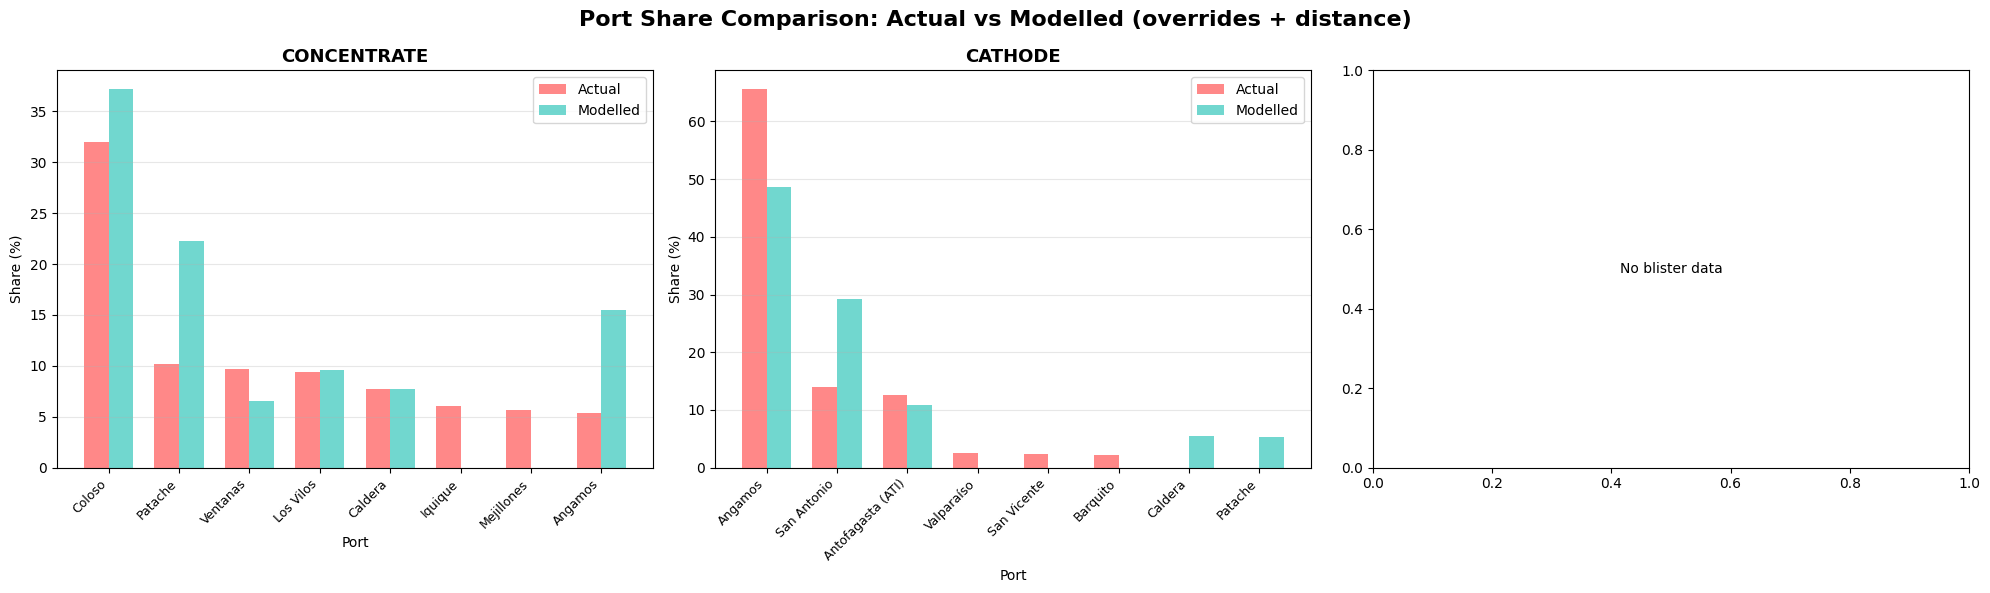

In [590]:

section_header("6. DISTANCE-BASED PORT ASSIGNMENT ANALYSIS")

mines = inv[
    (inv["CHAIN_STAGE"] == "extraction") & inv["LATITUD"].notna() &
    inv["LONGITUD"].notna() & (inv["COCHILCO_CU_2024_KMT"].notna()) &
    (inv["COCHILCO_CU_2024_KMT"] > 0)
].copy()

# FIX: also include sx_ew facilities that have COCHILCO production matched
# directly (e.g. Zaldivar, Tres Valles) - these are pure SX-EW operations
# where no separate mine record exists in the inventory.
sxew_producers = inv[
    (inv["CHAIN_STAGE"] == "sx_ew") & inv["LATITUD"].notna() &
    inv["LONGITUD"].notna() & (inv["COCHILCO_CU_2024_KMT"].notna()) &
    (inv["COCHILCO_CU_2024_KMT"] > 0) &
    ~inv["FACILITY_NAME"].isin(mines["FACILITY_NAME"])  # not already in mines
].copy()

if len(sxew_producers) > 0:
    print(f"  Adding {len(sxew_producers)} SX-EW producers with direct production data:")
    for _, r in sxew_producers.iterrows():
        print(f"    {r['FACILITY_NAME']:<45} {r['COCHILCO_CU_2024_KMT']:.1f} kMT")
    mines = pd.concat([mines, sxew_producers], ignore_index=True)

print(f"Mines with production data: {len(mines)}")
print(f"Ports: {len(ports_df)}")

# ── Product type classification ────────────────────────────────────────────
#
# Determines whether each mine's copper output leaves Chile as concentrate,
# cathode (SX-EW or fire-refined), or blister.
#
# Priority: (1) hardcoded override, (2) comm_col on the mine record,
# (3) nearby non-mine facilities in inventory, (4) mode of PRODUCT_FORM in links.
#
# Key corrections vs. the prior run:
# - Codelco mines (Chuquicamata, El Teniente, Radomiro Tomic, etc.) are marked
#   'cathode' because their concentrate is processed onsite/nearby and the final
#   export product is refined cathode, routed via CODELCO_CATHODE_ROUTING.
# - Pure SX-EW mines (Zaldívar, Tres Valles, Antucoya, etc.) are 'cathode'.
# - Mines that ship raw concentrate for third-party smelting remain 'concentrate'.

# PRODUCT_TYPE_OVERRIDE is defined in pipeline_constants.py (imported above).
# It now includes 'Rio Blanco': 'cathode' to cover División Andina's primary
# ore body, which was missing from the original notebook definition.
# Do NOT redefine here — edit pipeline_constants.py to change routing rules.

def classify_mine_product(mine_name):
    # 1. Hardcoded overrides (highest priority)
    for key, ptype in PRODUCT_TYPE_OVERRIDE.items():
        if key.lower() in mine_name.lower():
            return ptype

    # 2. Check comm_col on the mine record directly
    mine_rows = inv[
        inv["FACILITY_NAME"].str.contains(mine_name, case=False, na=False, regex=False) &
        inv["FACILITY_TYPE"].str.contains("Mine", case=False, na=False)
    ]
    if len(mine_rows) > 0 and comm_col in mine_rows.columns:
        comm_str = str(mine_rows.iloc[0].get(comm_col, "")).lower()
        if "cathode" in comm_str or "sxew" in comm_str:
            return "cathode"
        if "concentrate" in comm_str:
            return "concentrate"
        if "blister" in comm_str:
            return "blister"

    # 3. Nearby non-mine facilities in inventory
    tokens = mine_name.split()
    search_terms = [" ".join(tokens[:2])] if len(tokens) >= 2 and tokens[0] in ("El", "Los", "Las", "La") else []
    search_terms.append(tokens[0] if len(tokens[0]) >= 5 else mine_name)
    for term in search_terms:
        candidates = inv[
            inv["FACILITY_NAME"].str.contains(term, case=False, na=False, regex=False) &
            ~inv["FACILITY_TYPE"].str.contains("Mine|Prospect", case=False, na=False)
        ]
        if len(candidates) > 0:
            stages = set(candidates["CHAIN_STAGE"].dropna())
            if stages & {"concentration", "smelting", "processing"}: return "concentrate"
            if "sx_ew" in stages: return "cathode"

    # 4. Fallback: mode of PRODUCT_FORM in links table
    mine_links = links[links["MINE_NAME"] == mine_name]
    if len(mine_links) > 0:
        mode = mine_links["PRODUCT_FORM"].value_counts().index[0]
        return {"concentrate": "concentrate", "cathode_sxew": "cathode",
                "cathode_er": "cathode", "blister": "blister"}.get(mode, "unknown")
    return "unknown"

mines["product_type"] = mines["FACILITY_NAME"].apply(classify_mine_product)
print(f"\nMines by product type:\n{mines['product_type'].value_counts().to_string()}")

# Warn on unclassified mines so no production is silently excluded
unknown_mines = mines[mines["product_type"] == "unknown"]
if len(unknown_mines) > 0:
    unknown_prod  = unknown_mines["COCHILCO_CU_2024_KMT"].sum()
    total_prod    = mines["COCHILCO_CU_2024_KMT"].sum()
    print(f"\nWARNING: {len(unknown_mines)} mines ({unknown_prod:.1f} kMT, "
          f"{unknown_prod/total_prod*100:.1f}% of total) unclassified and excluded from port shares:")
    for _, r in unknown_mines.iterrows():
        print(f"  {r['FACILITY_NAME']:<45} {r['COCHILCO_CU_2024_KMT']:>8.1f} kMT")

# ── Vectorised distance matrix ─────────────────────────────────────────────
# Full mine x port distance matrix computed in one numpy broadcasting pass.

lat_m = np.radians(mines["LATITUD"].values)          # shape (M,)
lon_m = np.radians(mines["LONGITUD"].values)
lat_p = np.radians(ports_df["lat"].values)           # shape (P,)
lon_p = np.radians(ports_df["lon"].values)

dlat = lat_m[:, None] - lat_p[None, :]               # (M, P)
dlon = lon_m[:, None] - lon_p[None, :]
a    = (np.sin(dlat / 2) ** 2
        + np.cos(lat_m[:, None]) * np.cos(lat_p[None, :])
        * np.sin(dlon / 2) ** 2)
distances = 6371.0 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

distance_df = pd.DataFrame(
    distances,
    index=mines["FACILITY_NAME"].values,
    columns=ports_df["name"].values,
)

# ── Port assignment: dedicated overrides > Codelco routing > nearest ────────

def assign_port(mine_row, dist_row):
    """Assign port using: dedicated override > Codelco routing > nearest distance."""
    mine_name = mine_row["FACILITY_NAME"].lower()
    product   = mine_row["product_type"]

    # 1. Dedicated port override (contractual)
    for key, port_name in DEDICATED_PORT.items():
        if key.lower() in mine_name and port_name in dist_row.index:
            return port_name, dist_row[port_name]

    # 2. Codelco cathode consolidation
    if product == "cathode":
        for key, port_name in CODELCO_CATHODE_ROUTING.items():
            if key.lower() in mine_name and port_name in dist_row.index:
                return port_name, dist_row[port_name]

    # 3. Nearest port by straight-line distance (default)
    return dist_row.idxmin(), dist_row.min()

assigned_ports, assigned_dists = [], []
for i, (_, mine_row) in enumerate(mines.iterrows()):
    port_name, port_dist = assign_port(mine_row, distance_df.iloc[i])
    assigned_ports.append(port_name)
    assigned_dists.append(port_dist)

mines["nearest_port"] = assigned_ports
mines["distance_km"]  = assigned_dists

print(f"\nTop 10 mines by production with assigned port:")
for _, mine in mines.nlargest(10, "COCHILCO_CU_2024_KMT").iterrows():
    mine_lower = mine["FACILITY_NAME"].lower()
    is_override = (
        any(k.lower() in mine_lower for k in DEDICATED_PORT) or
        (mine["product_type"] == "cathode" and
         any(k.lower() in mine_lower for k in CODELCO_CATHODE_ROUTING))
    )
    marker = " [override]" if is_override else ""
    print(f"  {mine['FACILITY_NAME']:<40} -> {mine['nearest_port']:<25} "
          f"({mine['distance_km']:.0f} km, {mine['COCHILCO_CU_2024_KMT']:.1f} kMT){marker}")

# ── Simulated port shares by product type ─────────────────────────────────

simulated_shares = {}
for product_type in ["concentrate", "cathode", "blister"]:
    product_mines = mines[mines["product_type"] == product_type]
    if len(product_mines) == 0: continue
    total_production = product_mines["COCHILCO_CU_2024_KMT"].sum()
    port_production  = product_mines.groupby("nearest_port")["COCHILCO_CU_2024_KMT"].sum()
    port_shares = (port_production / total_production).to_dict()
    simulated_shares[product_type] = {k: v for k, v in port_shares.items() if v >= 0.01}
    print(f"\n{product_type.upper()} (modelled):")
    for port, share in sorted(simulated_shares[product_type].items(), key=lambda x: -x[1]):
        print(f"  {port:<30} {share*100:>6.1f}%")

# ── Compare to actual Aduanas port shares ─────────────────────────────────
# Expected file: Chile_Port_Shares_Aduanas.csv
# Required columns: PORT, PRODUCT (concentrate/cathode/blister), FOB_SHARE (0-1)

port_shares_path = os.path.join(DIR_PRELIM, "Chile_Port_Shares_Aduanas.csv")
if os.path.exists(port_shares_path):
    actual_shares_df = pd.read_csv(port_shares_path)
    # Use ADUANAS_PORT_ALIAS from pipeline_constants.py for port name normalisation.
    # Source: Aduanas all-caps Spanish -> mixed-case English used in PORTS list.
    # Risk: the alias dict may not cover all codes in newer Salidas files;
    # review ADUANAS_PORT_ALIAS in pipeline_constants.py if a port is unmapped.
    actual_shares_df["PORT"] = actual_shares_df["PORT"].replace(ADUANAS_PORT_ALIAS)

    actual_shares = {}
    for product in ["concentrate", "cathode", "blister"]:
        product_data = actual_shares_df[actual_shares_df["PRODUCT"] == product]
        if len(product_data) == 0: continue
        port_share_dict = product_data.groupby("PORT")["FOB_SHARE"].sum().to_dict()
        actual_shares[product] = {k: v for k, v in port_share_dict.items() if v >= 0.01}
        print(f"\n{product.upper()} (actual, Aduanas):")
        for port, share in sorted(actual_shares[product].items(), key=lambda x: -x[1]):
            print(f"  {port:<30} {share*100:>6.1f}%")

    section_header("COMPARISON: ACTUAL vs MODELLED")
    comparison_results = []
    for product_type in ["concentrate", "cathode", "blister"]:
        if product_type not in simulated_shares: continue
        actual    = actual_shares.get(product_type, {})
        simulated = simulated_shares[product_type]
        all_ports = set(actual.keys()) | set(simulated.keys())
        print(f"\n{product_type.upper()}\n" + "-" * 75)
        for port in sorted(all_ports):
            a, s = actual.get(port, 0), simulated.get(port, 0)
            diff = s - a
            indicator = "=" if abs(diff) < 0.02 else ("^ (would gain)" if diff > 0 else "v (would lose)")
            comparison_results.append({"product": product_type, "port": port,
                                       "actual_share": a, "simulated_share": s, "difference": diff})
            print(f"  {port:<30} Actual: {a*100:5.1f}%  |  Modelled: {s*100:5.1f}%  |  D {diff*100:+6.1f}% {indicator}")

    comparison_df = pd.DataFrame(comparison_results)

    section_header("SUMMARY STATISTICS")
    for product_type in ["concentrate", "cathode", "blister"]:
        pc = comparison_df[comparison_df["product"] == product_type]
        if len(pc) == 0: continue
        print(f"\n{product_type.upper()}:")
        print(f"  Mean Absolute Difference: {pc['difference'].abs().mean()*100:.1f}%")
        print(f"  Total Volume Mismatch:    {pc['difference'].abs().sum()/2*100:.1f}%")

    # ── Structural limitation note ──────────────────────────────────────────
    # The mismatch figures above (~20-30% mean absolute deviation) reflect a
    # known structural limitation: this model assigns each mine to a SINGLE port
    # using a priority order (override → dedicated → nearest-by-distance). Real
    # operators split shipments across multiple ports depending on vessel
    # availability, contract terms, and seasonal capacity constraints. A
    # single-port routing model systematically over-assigns to the
    # geographically nearest terminal and under-assigns to secondary ports.
    # These figures are NOT errors in the pipeline — they document the gap
    # between a simplified routing model and observed Aduanas data.
    print("\nNOTE: Mismatch figures reflect single-port routing assumption.")
    print("  Real operators split shipments across multiple ports; the model cannot")
    print("  capture this without mine-level shipment data. See pipeline documentation.")
    comparison_df.to_csv(os.path.join(DIR_PRELIM, "Port_Distance_Comparison.csv"), index=False)
    mines[["FACILITY_NAME", "COCHILCO_CU_2024_KMT", "product_type",
           "nearest_port", "distance_km"]].to_csv(
        os.path.join(DIR_PRELIM, "Mine_Optimal_Port_Assignments.csv"), index=False)
    distance_df.to_csv(os.path.join(DIR_PRELIM, "Mine_Port_Distance_Matrix.csv"))

    # ── Visualisation ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("Port Share Comparison: Actual vs Modelled (overrides + distance)",
                 fontsize=16, fontweight="bold")
    colors = {"actual": "#FF6B6B", "simulated": "#4ECDC4"}

    for idx, product in enumerate(["concentrate", "cathode", "blister"]):
        ax = axes[idx]
        if product not in simulated_shares:
            ax.text(0.5, 0.5, f"No {product} data", ha="center", va="center", transform=ax.transAxes)
            continue
        pd_data = comparison_df[comparison_df["product"] == product].copy()
        pd_data = pd_data.sort_values("actual_share", ascending=False)
        pd_data = pd_data[(pd_data["actual_share"] >= 0.01) | (pd_data["simulated_share"] >= 0.01)].head(8)
        if len(pd_data) == 0: continue
        x     = np.arange(len(pd_data))
        width = 0.35
        ax.bar(x - width/2, pd_data["actual_share"]    * 100, width, label="Actual",   color=colors["actual"],    alpha=0.8)
        ax.bar(x + width/2, pd_data["simulated_share"] * 100, width, label="Modelled", color=colors["simulated"], alpha=0.8)
        ax.set_xlabel("Port"); ax.set_ylabel("Share (%)")
        ax.set_title(f"{product.upper()}", fontsize=13, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(pd_data["port"], rotation=45, ha="right", fontsize=9)
        ax.legend(); ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(DIR_PRELIM, "Port_Comparison_Chart.png"), dpi=300, bbox_inches="tight")
    print(f"\nChart saved: Port_Comparison_Chart.png")
    plt.show()

else:
    print("\nWarning: Chile_Port_Shares_Aduanas.csv not found — only modelled shares computed.")
    print(f"  Expected path: {port_shares_path}")
    print("  Required columns: PORT, PRODUCT (concentrate/cathode/blister), FOB_SHARE (0-1 decimal)")
    comparison_df = pd.DataFrame()
    mines[["FACILITY_NAME", "COCHILCO_CU_2024_KMT", "product_type",
           "nearest_port", "distance_km"]].to_csv(
        os.path.join(DIR_PRELIM, "Mine_Optimal_Port_Assignments.csv"), index=False)
    distance_df.to_csv(os.path.join(DIR_PRELIM, "Mine_Port_Distance_Matrix.csv"))
    print("Saved: Mine_Optimal_Port_Assignments.csv, Mine_Port_Distance_Matrix.csv")


## 7: Pipeline Summary & Integrity Checks

In [591]:
section_header("1. INVENTORY SUMMARY")

print(f"Total facilities:  {len(inv)}")
print(f"Idle mines:        {len(idle_mines)}")
print(f"Idle links removed:{n_idle_links}")

print("\nFacility types:")
for ftype, n in inv["FACILITY_TYPE"].value_counts().items():
    print(f"  {ftype:<40} {n:>5}")

print("\nCommodity coverage (facilities with each commodity):")
comm_counts = {}
for val in inv[comm_col].dropna():
    for c in [x.strip() for x in str(val).split(",") if x.strip()]:
        comm_counts[c] = comm_counts.get(c, 0) + 1
for comm, n in sorted(comm_counts.items(), key=lambda x: -x[1]):
    print(f"  {comm:<25} {n:>5} facilities")

# ── Integrity label ─────────────────────────────────────────────────────────
_n_no_coords = inv["LATITUD"].isna().sum()
_n_no_comm   = inv[comm_col].isna().sum()
if _n_no_coords == 0 and _n_no_comm == 0:
    print("\nCHECK 1 (Inventory summary): PASS")
elif _n_no_coords < 30 and _n_no_comm < 30:
    print(f"\nCHECK 1 (Inventory summary): WARN  (missing coords: {_n_no_coords}, missing commodity: {_n_no_comm})")
else:
    print(f"\nCHECK 1 (Inventory summary): FAIL  (missing coords: {_n_no_coords}, missing commodity: {_n_no_comm})")



1. INVENTORY SUMMARY
Total facilities:  461
Idle mines:        80
Idle links removed:263

Facility types:
  Processing Plant                           123
  Prospect/Project                           113
  Mine (idle)                                 80
  Mine (active)                               74
  SX-EW Plant                                 23
  Concentrator                                22
  Smelter                                     14
  Refinery                                     4
  Grinding Plant                               4
  Pellet Plant                                 2
  Steel Plant                                  2

Commodity coverage (facilities with each commodity):
  Copper                      193 facilities
  Gold                        103 facilities
  Silver                       63 facilities
  Molybdenum                   44 facilities
  Iron                         26 facilities
  Nitrate                      21 facilities
  Iodine                      

In [592]:
section_header("2. SUPPLY CHAIN EDGES")

print(f"Total edges: {len(edges)}")

print("\nEdge types:")
for et, n in edges["EDGE_TYPE"].value_counts().sort_index().items():
    print(f"  {et:<35} {n:>5}")

print("\nCommodities in edges:")
for comm, n in edges["COMMODITIES"].value_counts().items():
    print(f"  {comm:<25} {n:>5} edges")

print("\nProduct forms:")
for pf, n in edges["PRODUCT_FORM"].value_counts().items():
    print(f"  {pf:<25} {n:>5} edges")

# ── Integrity label ─────────────────────────────────────────────────────────
_n_edges = len(edges)
_n_mine2plant = (edges["EDGE_TYPE"] == "mine_to_plant").sum()
if _n_edges > 500 and _n_mine2plant > 100:
    print(f"\nCHECK 2 (Supply chain edges): PASS  ({_n_edges} total edges, {_n_mine2plant} mine_to_plant)")
elif _n_edges > 0:
    print(f"\nCHECK 2 (Supply chain edges): WARN  ({_n_edges} edges, {_n_mine2plant} mine_to_plant — lower than expected)")
else:
    print("\nCHECK 2 (Supply chain edges): FAIL  (no edges in table)")



2. SUPPLY CHAIN EDGES
Total edges: 2386

Edge types:
  boron_to_port                           3
  concentrate_to_port                     6
  concentrate_to_smelter                  7
  gold_to_airport                         8
  iodine_to_port                          6
  iron_to_port                            7
  lithium_to_port                         3
  mine_to_mo_plant                       12
  mine_to_plant                        1154
  mine_to_smelter                        32
  mo_to_port                              4
  mo_to_re_plant                          4
  nitrate_to_port                         7
  port_to_country                      1065
  processing_to_port                     19
  rhenium_to_port                         1
  silver_to_airport                       6
  smelter_to_port                        15
  sxew_to_port                           25
  zinc_to_port                            2

Commodities in edges:
  Copper                     1320 edges
  N

In [593]:
section_header("3. COPPER PRODUCTION COVERAGE")

cu_col = "COCHILCO_CU_2024_KMT"
cu_inv = inv[inv[cu_col].notna() & (inv[cu_col] > 0)].copy()
cu_inv = cu_inv.sort_values(cu_col, ascending=False)

print(f"Active Cu producers in inventory: {len(cu_inv)}")
print(f"Total Cu 2024 (kMT):              {cu_inv[cu_col].sum():.1f}")
print(f"Cu total from state:              {cu_total:.1f}")

print("\nTop 15 Cu producers:")
for _, row in cu_inv.head(15).iterrows():
    prod = row[cu_col]
    share = prod / cu_inv[cu_col].sum() * 100
    print(f"  {row['FACILITY_NAME']:<45} {prod:>7.1f} kMT  ({share:>5.1f}%)")

# ── Integrity label ─────────────────────────────────────────────────────────
_cu_sum = cu_inv["COCHILCO_CU_2024_KMT"].sum() if len(cu_inv) > 0 else 0
_coverage = _cu_sum / cu_total * 100 if cu_total > 0 else 0
if _coverage >= 90:
    print(f"\nCHECK 3 (Cu production coverage): PASS  ({_coverage:.1f}% of national total matched)")
elif _coverage >= 70:
    print(f"\nCHECK 3 (Cu production coverage): WARN  ({_coverage:.1f}% matched — below 90% threshold)")
else:
    print(f"\nCHECK 3 (Cu production coverage): FAIL  ({_coverage:.1f}% matched — significant gap)")



3. COPPER PRODUCTION COVERAGE
Active Cu producers in inventory: 31
Total Cu 2024 (kMT):              5281.6
Cu total from state:              5281.6

Top 15 Cu producers:
  Escondida                                      1277.5 kMT  ( 24.2%)
  Collahuasi                                      558.6 kMT  ( 10.6%)
  El Teniente                                     356.4 kMT  (  6.7%)
  Los Pelambres                                   331.2 kMT  (  6.3%)
  Chuquicamata                                    289.0 kMT  (  5.5%)
  Radomiro Tomic                                  270.5 kMT  (  5.1%)
  Spence                                          255.6 kMT  (  4.8%)
  Quebrada Blanca                                 207.8 kMT  (  3.9%)
  Andina                                          181.6 kMT  (  3.4%)
  Los Bronces                                     172.4 kMT  (  3.3%)
  Sierra Gorda                                    154.6 kMT  (  2.9%)
  Candelaria                                      142.1 kM

In [594]:
section_header("4. CONNECTIVITY CHECKS")

# ── Graph reachability: every copper mine should reach at least one port ──
# This is a proper BFS over the full edge table, not just a membership check
# in the mine_to_plant FROM_NAME list. A mine passes iff there exists at least
# one directed path mine -> ... -> port in the edge DAG.

_port_names = {p["name"] for p in PORTS}

# Build adjacency dict from the full edge table (directed graph)
from collections import deque, defaultdict
_adj = defaultdict(set)
for _, row in edges.iterrows():
    _adj[row["FROM_NAME"]].add(row["TO_NAME"])

def _reaches_port(start_name: str) -> bool:
    """BFS: return True if start_name can reach any known port node."""
    visited = {start_name}
    queue = deque([start_name])
    while queue:
        node = queue.popleft()
        if node in _port_names:
            return True
        for nbr in _adj.get(node, set()):
            if nbr not in visited:
                visited.add(nbr)
                queue.append(nbr)
    return False

# Active mines in inventory
active_mines = inv[inv["FACILITY_TYPE"].str.contains("Mine", case=False, na=False)
                   & ~inv["FACILITY_TYPE"].str.contains("idle", case=False, na=False)]

# Mines referenced in edges (simple membership check for connectivity)
mine_names_in_edges = set(edges[edges["EDGE_TYPE"] == "mine_to_plant"]["FROM_NAME"].unique())

connected = active_mines[active_mines["FACILITY_NAME"].isin(mine_names_in_edges)]
unconnected = active_mines[~active_mines["FACILITY_NAME"].isin(mine_names_in_edges)]

print(f"Active mines in inventory:    {len(active_mines)}")
print(f"Mines with mine_to_plant edge:{len(connected)}")
print(f"Mines with no edges:          {len(unconnected)}")

# ── BFS reachability for copper producers specifically ────────────────────
cu_mines = active_mines[
    active_mines["COCHILCO_CU_2024_KMT"].notna() &
    (active_mines["COCHILCO_CU_2024_KMT"] > 0)
]
port_reachable = [nm for nm in cu_mines["FACILITY_NAME"] if _reaches_port(nm)]
port_unreachable = [nm for nm in cu_mines["FACILITY_NAME"] if not _reaches_port(nm)]

print(f"\nCopper producers with graph-reachable port: {len(port_reachable)} / {len(cu_mines)}")
if port_unreachable:
    print("WARN: copper producers that cannot reach any port via edge graph:")
    for nm in port_unreachable:
        cu = cu_mines.loc[cu_mines["FACILITY_NAME"] == nm, "COCHILCO_CU_2024_KMT"].values[0]
        print(f"  {nm:<45} {cu:.1f} kMT")
else:
    print("  All copper producers reach at least one port. PASS")

if len(unconnected) > 0:
    print("\nUnconnected mines (no mine_to_plant edge):")
    for _, row in unconnected.iterrows():
        cu = row.get("COCHILCO_CU_2024_KMT", float("nan"))
        comm = row.get(comm_col, "")
        print(f"  {row['FACILITY_NAME']:<45} Cu={cu}  {comm}")

# ── Integrity label ─────────────────────────────────────────────────────────
if len(port_unreachable) == 0 and len(unconnected) == 0:
    print("\nCHECK 4 (Connectivity): PASS")
elif len(port_unreachable) == 0:
    print(f"\nCHECK 4 (Connectivity): WARN  ({len(unconnected)} active mines have no edges, but all Cu producers reach a port)")
else:
    print(f"\nCHECK 4 (Connectivity): FAIL  ({len(port_unreachable)} Cu producers cannot reach any port)")



4. CONNECTIVITY CHECKS
Active mines in inventory:   74
Mines with supply chain edge:71
Mines with no edges:         3

Unconnected mines:
  Andacollo Oro                                 Cu=nan  Gold
  El Sauce                                      Cu=nan  Copper
  Pampa Camarones                               Cu=nan  Copper


In [595]:
section_header("5. DATA QUALITY")

# Missing coordinates
no_lat = inv[inv["LATITUD"].isna()]
no_lon = inv[inv["LONGITUD"].isna()]
print(f"Facilities missing LATITUD:  {len(no_lat)}")
print(f"Facilities missing LONGITUD: {len(no_lon)}")

# Missing coordinates by type
if len(no_lat) > 0:
    print("\nMissing coords by facility type:")
    for ftype, n in no_lat["FACILITY_TYPE"].value_counts().items():
        print(f"  {ftype:<40} {n:>5}")

# Edges with missing distances
no_dist = edges[edges["DISTANCE_KM"].isna()]
print(f"\nEdges with missing DISTANCE_KM: {len(no_dist)}")
if len(no_dist) > 0:
    print("  Edge types affected:")
    for et, n in no_dist["EDGE_TYPE"].value_counts().items():
        print(f"    {et:<35} {n:>5}")

# Duplicate edges
dup_cols = ["FROM_NAME","TO_NAME","EDGE_TYPE","COMMODITIES","PRODUCT_FORM"]
dupes = edges[edges.duplicated(subset=dup_cols, keep=False)]
print(f"\nDuplicate edges: {len(dupes)}")
if len(dupes) > 0:
    print(dupes[dup_cols].drop_duplicates().to_string(index=False))

# ── Integrity label ─────────────────────────────────────────────────────────
# port_to_country edges do not carry DISTANCE_KM by design (cross-ocean).
# Exclude them from the missing-distance check.
_no_dist_physical = edges[
    edges["EDGE_TYPE"] != "port_to_country"]["DISTANCE_KM"].isna().sum()
_no_dist_all = edges["DISTANCE_KM"].isna().sum()
_dupes_n = len(edges[edges.duplicated(subset=["FROM_NAME","TO_NAME","EDGE_TYPE","COMMODITIES","PRODUCT_FORM"], keep=False)])
print(f"  (port_to_country edges without distance: {_no_dist_all - _no_dist_physical} — expected, no action needed)")
if _no_dist_physical == 0 and _dupes_n == 0:
    print("\nCHECK 5 (Data quality): PASS")
elif _no_dist_physical < 20 and _dupes_n < 10:
    print(f"\nCHECK 5 (Data quality): WARN  (missing DISTANCE_KM in physical edges: {_no_dist_physical}, duplicate edges: {_dupes_n})")
else:
    print(f"\nCHECK 5 (Data quality): FAIL  (missing DISTANCE_KM in physical edges: {_no_dist_physical}, duplicate edges: {_dupes_n})")



5. DATA QUALITY
Facilities missing LATITUD:  0
Facilities missing LONGITUD: 0

Edges with missing DISTANCE_KM: 1065
  Edge types affected:
    port_to_country                      1065

Duplicate edges: 0


In [596]:
section_header("6. EXPORT DESTINATIONS")

if export_df.empty:
    print("  export_df not available in state.")
else:
    print(f"Export records: {len(export_df)}")
    # Export edges use TO_NAME for destination country and COMMODITIES for commodity.
    # The original check for "DESTINATION_COUNTRY" / "COMMODITY" was wrong and
    # would silently skip — fixed to use the actual column names.
    if "TO_NAME" in export_df.columns:
        country_edges = export_df[export_df["EDGE_TYPE"] == "port_to_country"] if "EDGE_TYPE" in export_df.columns else export_df
        print(f"Destination countries: {country_edges['TO_NAME'].nunique()}")
        print("\nTop 15 destinations by export value:")
        val_col = next((c for c in ["EXPORT_VALUE", "FOB_USD"] if c in export_df.columns), None)
        if val_col:
            top = country_edges.groupby("TO_NAME")[val_col].sum().sort_values(ascending=False).head(15)
            for country, val in top.items():
                print(f"  {country:<30} {val:>15,.2f}")
        else:
            print("  (no EXPORT_VALUE column — value totals unavailable)")
    if "COMMODITIES" in export_df.columns:
        print("\nCommodities in exports:")
        for comm, n in export_df["COMMODITIES"].value_counts().items():
            print(f"  {comm:<25} {n:>6} edges")

# ── Integrity label ─────────────────────────────────────────────────────────
if export_df.empty:
    print("\nCHECK 6 (Export destinations): WARN  (export_df is empty — Aduanas data not loaded)")
elif len(export_df) > 10:
    print(f"\nCHECK 6 (Export destinations): PASS  ({len(export_df)} export records)")
else:
    print(f"\nCHECK 6 (Export destinations): WARN  ({len(export_df)} export records — very low)")



6. EXPORT DESTINATIONS
Export records: 1065


In [597]:
section_header("7. PORT UTILISATION")

# Only physical Chilean ports — exclude port_to_country edges
port_names = {p['name'] for p in PORTS}
port_edges = edges[
    (edges['TO_NAME'].isin(port_names) | edges['FROM_NAME'].isin(port_names))
    & (edges['EDGE_TYPE'] != 'port_to_country')
]

print(f'Edges touching Chilean ports: {len(port_edges)}')
print('\nEdges per port (arrivals + departures):')
from collections import Counter
port_counts = Counter()
for _, row in port_edges.iterrows():
    if row['TO_NAME'] in port_names:
        port_counts[row['TO_NAME']] += 1
    if row['FROM_NAME'] in port_names:
        port_counts[row['FROM_NAME']] += 1
for port_name, n in sorted(port_counts.items(), key=lambda x: -x[1]):
    print(f'  {port_name:<30} {n:>5} edges')

print(f'\nport_to_country export edges: {len(edges[edges["EDGE_TYPE"] == "port_to_country"])}')
print('(distances not calculated for export destination edges — expected)')

# ── Integrity label ─────────────────────────────────────────────────────────
_n_port_edges = len(port_edges)
_n_ports_used = len(port_counts)
if _n_ports_used >= 8:
    print(f"\nCHECK 7 (Port utilisation): PASS  ({_n_ports_used} ports used, {_n_port_edges} port-touching edges)")
elif _n_ports_used >= 4:
    print(f"\nCHECK 7 (Port utilisation): WARN  ({_n_ports_used} ports used — expected ≥8)")
else:
    print(f"\nCHECK 7 (Port utilisation): FAIL  ({_n_ports_used} ports used — most ports have no edges)")



7. PORT UTILISATION
Edges touching Chilean ports: 91

Edges per port (arrivals + departures):
  Angamos                           18 edges
  Caldera                           11 edges
  Antofagasta (ATI)                  8 edges
  Los Vilos                          8 edges
  Iquique                            8 edges
  San Antonio                        8 edges
  Ventanas                           8 edges
  Coquimbo                           7 edges
  Barquito                           6 edges
  Coloso                             5 edges
  Patache                            2 edges
  Mejillones                         2 edges

port_to_country export edges: 1065
(distances not calculated for export destination edges — expected)


In [598]:
section_header("8. OUTPUT FILE CHECK")

import glob
expected_files = [
    "Chile_Minerals_Inventory.csv",
    "Chile_Mine_Plant_Links.csv",
    "Chile_Supply_Chain_Edges.csv",
    "Chile_Export_Destinations.csv",
    "Chile_Ports.csv",
    "Mine_Port_Distance_Matrix.csv",
    "Mine_Optimal_Port_Assignments.csv",
]
print(f"Checking {DIR_INTERMED}:")
for fname in expected_files:
    path = os.path.join(DIR_INTERMED, fname)
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        try:
            df = pd.read_csv(path, nrows=1)
            n_cols = len(df.columns)
        except:
            n_cols = "?"
        print(f"  OK    {fname:<45} {size_kb:>8.1f} KB  {n_cols} cols")
    else:
        print(f"  MISSING {fname}")

pkl_files = sorted(glob.glob(os.path.join(DIR_INTERMED, "_pipeline_state_*.pkl")))
print(f"\nState files: {len(pkl_files)}")
for p in pkl_files:
    size_kb = os.path.getsize(p) / 1024
    print(f"  {os.path.basename(p):<35} {size_kb:>8.1f} KB")

# ── Integrity label ─────────────────────────────────────────────────────────
_missing = [f for f in expected_files if not os.path.exists(os.path.join(DIR_INTERMED, f))]
if len(_missing) == 0:
    print(f"\nCHECK 8 (Output files): PASS  (all {len(expected_files)} expected files present)")
elif len(_missing) <= 2:
    print(f"\nCHECK 8 (Output files): WARN  ({len(_missing)} missing: {_missing})")
else:
    print(f"\nCHECK 8 (Output files): FAIL  ({len(_missing)} missing: {_missing})")



8. OUTPUT FILE CHECK
Checking /Users/leoss/Desktop/Website-/Portfolio/Website-/projects/Chile/output/intermediary:
  OK    Chile_Minerals_Inventory.csv                     277.7 KB  163 cols
  OK    Chile_Mine_Plant_Links.csv                       311.5 KB  21 cols
  OK    Chile_Supply_Chain_Edges.csv                     280.4 KB  12 cols
  OK    Chile_Export_Destinations.csv                    116.4 KB  15 cols
  OK    Chile_Ports.csv                                    1.0 KB  6 cols
  OK    Mine_Port_Distance_Matrix.csv                      7.8 KB  14 cols
  OK    Mine_Optimal_Port_Assignments.csv                  1.9 KB  5 cols

State files: 7
  _pipeline_state_0.pkl                  503.6 KB
  _pipeline_state_1.pkl                  523.7 KB
  _pipeline_state_2.pkl                  779.1 KB
  _pipeline_state_3.pkl                  643.1 KB
  _pipeline_state_4.pkl                  734.5 KB
  _pipeline_state_5.pkl                 1087.5 KB
  _pipeline_state_6.pkl                 1069

## Save Final State

In [599]:
# ── Save final state ─────────────────────────────────────────────────
state.update({
    'inv': inv, 'links': links, 'edges': edges,
    'export_df': export_df, 'ports_df': ports_df,
    'inv_path': inv_path, 'links_path': links_path,
    'cu_total': cu_total, 'n_idle_links': n_idle_links,
})
save_state(state, 6)
print("Final state saved as _pipeline_state_6.pkl")


State saved to /Users/leoss/Desktop/Website-/Portfolio/Website-/projects/Chile/output/intermediary/_pipeline_state_6.pkl
Final state saved as _pipeline_state_6.pkl


In [600]:
import sys
sys.path.insert(0, "/Users/leoss/Desktop/Website-/Portfolio/Website-/projects/Chile/Code")
from pipeline_utils import load_state
from commodity_prices_2024 import build_prices
import os

state = load_state(2)
inv = state['inv']

# Check that the expected production columns exist
for col in ["COCHILCO_CU_2024_KMT", "COCHILCO_MO_2024_MT", 
            "COCHILCO_AU_2024_KG", "COCHILCO_AG_2024_KG",
            "COCHILCO_FE_2024_KMT", "COCHILCO_ZN_2024_MT"]:
    n = inv[col].notna().sum() if col in inv.columns else 0
    print(f"  {col}: {n} non-null")

# Test price parsing
from pipeline_utils import COCHILCO_ORIG
prices_mt, prices_kg, _, _, _ = build_prices(anuario_path=COCHILCO_ORIG)
print("\nPrices (USD/MT):", prices_mt)
print("Prices (USD/kg):", prices_kg)

# Quick sanity: copper value
if "COCHILCO_CU_2024_KMT" in inv.columns and "Copper" in prices_mt:
    cu_total_mt = inv["COCHILCO_CU_2024_KMT"].sum() * 1000
    cu_value = cu_total_mt * prices_mt["Copper"]
    print(f"\nCopper: {cu_total_mt:,.0f} MT x ${prices_mt['Copper']:,.2f}/MT = ${cu_value/1e9:,.2f}B")

  COCHILCO_CU_2024_KMT: 31 non-null
  COCHILCO_MO_2024_MT: 12 non-null
  COCHILCO_AU_2024_KG: 20 non-null
  COCHILCO_AG_2024_KG: 12 non-null
  COCHILCO_FE_2024_KMT: 6 non-null
  COCHILCO_ZN_2024_MT: 2 non-null



Prices (USD/MT): {'Copper': 9146.769964199999, 'Aluminum': 2418.909064, 'Nickel': 16811.550271999997, 'Lead': 2072.563262, 'Tin': 30190.727666, 'Zinc': 2779.3644339999996, 'Molybdenum': 46953.996759999995, 'Alumina': 515.0, 'Boric Acid': 988.2, 'Lithium': 13250.0, 'Iodine': 76689.5}
Prices (USD/kg): {'Gold': 76580.94190589999, 'Silver': 906.6449173950001, 'Platinum': 30703.6934451}

Copper: 5,281,606 MT x $9,146.77/MT = $48.31B


In [601]:
PKL_PATH = '/Users/leoss/Desktop/Website-/Portfolio/Website-/projects/Chile/output/intermediary/_pipeline_state_6.pkl'
OUT_DIR  = '/Users/leoss/Desktop/Website-/Portfolio/Website-/projects/Chile/output/intermediary/chile_figures'

In [602]:
print(export_df['COMMODITIES'].unique())
print()
print(export_df.groupby('COMMODITIES')['EXPORT_VALUE'].sum().sort_values(ascending=False))

['Copper' 'Molybdenum' 'Lithium' 'Iodine' 'Gold' 'Silver' 'Iron' 'Zinc'
 'Nitrate' 'Boron' 'Salt' 'Potash' 'Rhenium' 'Lead' 'Copper Sulfate'
 'Sulfuric Acid' 'Selenium']

COMMODITIES
Iron              1.554434e+09
Gold              1.279581e+09
Nitrate           7.210324e+08
Silver            4.774251e+08
Salt              1.432724e+08
Potash            1.275631e+08
Boron             9.206627e+07
Zinc              6.629388e+07
Rhenium           4.179172e+07
Lead              3.074487e+07
Copper Sulfate    2.369833e+07
Sulfuric Acid     2.910632e+06
Selenium          1.496584e+06
Molybdenum        1.116588e+04
Copper            5.852400e+03
Lithium           2.626560e+03
Iodine            1.438990e+03
Name: EXPORT_VALUE, dtype: float64


In [ ]:
"""
Chile Mineral Supply Chain: Production & Export Visualisations
==============================================================
Generates 10 standalone Plotly HTML charts from _pipeline_state_6.pkl.

Charts produced:
  01  Treemap         – Production value by mineral category > mineral
  02  Horizontal bar  – Top 20 facilities (with Cu/non-Cu toggle buttons)
  03  Scattergeo      – Facility map (sized by value, coloured by mineral group)
  04  Port map        – Chilean ports with copper export volumes by product form
  05  Choropleth      – Copper export destinations (world map)
  06  Stacked bar     – Regional value breakdown by mineral group
  07  Sunburst        – Region > Mineral Group > Mineral drilldown
  08  Grouped bar     – Export destinations for 4 exported commodities
  09  Scatter         – Copper mines: output vs non-copper by-product value
  10  Horizontal bar  – Non-copper mineral values (log scale)

Requirements: plotly, pandas, numpy
Run: python3 chile_viz.py
Reads: _pipeline_state_6.pkl (from uploads or local)
Writes: 10 HTML files to /mnt/user-data/outputs/ (or ./outputs/ locally)
"""

import pickle, os, sys
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# ── STYLE ────────────────────────────────────────────────────────────────────

STYLE = {
    'font_family': 'Public Sans, -apple-system, BlinkMacSystemFont, sans-serif',
    'tick_size': 11,
    'axis_title_size': 13,
    'legend_size': 11,
    'annotation_size': 10,
    'title_color': '#1a2744',
    'template': 'plotly_white',
    'plot_bg': '#fafafa',
    'paper_bg': '#fafafa',
    'chart_height': 550,
    'chart_height_small': 420,
    'chart_height_tall': 700,
    'margin': dict(l=60, r=40, t=10, b=50),
    'margin_map': dict(l=10, r=10, t=10, b=60),
    'margin_bar': dict(l=160, r=130, t=10, b=50),
    'grid_color': '#e5e7eb',
    'grid_width': 0.5,
    'zero_line_color': '#c9cfd6',
    'geo': dict(
        showframe=False, showcoastlines=True, coastlinecolor='#c9cfd6',
        projection_type='natural earth', bgcolor='rgba(0,0,0,0)',
        showland=True, landcolor='#f0f2f5', showcountries=True,
        countrycolor='#dde1e7', countrywidth=0.5,
    ),
    'choropleth_line_color': '#c9cfd6',
    'choropleth_line_width': 0.5,
    'colorbar': dict(len=0.7, thickness=15),
}

WRITE_CONFIG = {'displayModeBar': False, 'responsive': True}

# ── MINERAL GROUPING ─────────────────────────────────────────────────────────

MINERAL_GROUPS = {
    'USD_VALUE_CU':        ('Copper',            'Base metals'),
    'USD_VALUE_MO':        ('Molybdenum',        'Base metals'),
    'USD_VALUE_FE':        ('Iron',              'Base metals'),
    'USD_VALUE_ZN':        ('Zinc',              'Base metals'),
    'USD_VALUE_PB':        ('Lead',              'Base metals'),
    'USD_VALUE_AU':        ('Gold',              'Precious metals'),
    'USD_VALUE_AG':        ('Silver',            'Precious metals'),
    'USD_VALUE_LICO3':     ('Lithium Carbonate', 'Battery/strategic'),
    'USD_VALUE_LIOH':      ('Lithium Hydroxide', 'Battery/strategic'),
    'USD_VALUE_LISO4':     ('Lithium Sulfate',   'Battery/strategic'),
    'USD_VALUE_IO':        ('Iodine',            'Battery/strategic'),
    'USD_VALUE_NO3':       ('Nitrates',          'Industrial minerals'),
    'USD_VALUE_ULEXITE':   ('Ulexite',           'Industrial minerals'),
    'USD_VALUE_BORICACID': ('Boric Acid',        'Industrial minerals'),
    'USD_VALUE_KCL':       ('Potash',            'Industrial minerals'),
    'USD_VALUE_SALT':      ('Salt',              'Industrial minerals'),
    'USD_VALUE_CUSO4':     ('Copper Sulfate',    'Industrial minerals'),
    'USD_VALUE_LIMESTONE': ('Limestone',         'Industrial minerals'),
    'USD_VALUE_COQUINA':   ('Coquina',           'Industrial minerals'),
    'USD_VALUE_WHITECACO3':('White CaCO3',       'Industrial minerals'),
    'USD_VALUE_GYPSUM':    ('Gypsum',            'Industrial minerals'),
    'USD_VALUE_PUMICITE':  ('Pumicite',          'Industrial minerals'),
    'USD_VALUE_QUARTZ':    ('Quartz',            'Industrial minerals'),
    'USD_VALUE_SILICASAND':('Silica Sand',       'Industrial minerals'),
    'USD_VALUE_BAUXCLAY':  ('Bauxitic Clay',     'Industrial minerals'),
    'USD_VALUE_KAOLIN':    ('Kaolin',            'Industrial minerals'),
    'USD_VALUE_BENTONITE': ('Bentonite',         'Industrial minerals'),
    'USD_VALUE_DIATOMITE': ('Diatomite',         'Industrial minerals'),
    'USD_VALUE_DOLOMITE':  ('Dolomite',          'Industrial minerals'),
    'USD_VALUE_TALC':      ('Talc',              'Industrial minerals'),
    'USD_VALUE_PERLITE':   ('Perlite',           'Industrial minerals'),
    'USD_VALUE_PEAT':      ('Peat',              'Industrial minerals'),
    'USD_VALUE_PHOSPHATE': ('Phosphate Rocks',   'Industrial minerals'),
    'USD_VALUE_ZEOLITE':   ('Zeolite',           'Industrial minerals'),
}

GROUP_COLORS = {
    'Base metals':         '#4a6fa5',
    'Precious metals':     '#d4853b',
    'Battery/strategic':   '#2e7d4a',
    'Industrial minerals': '#c23a3a',
}

# Finer colours for individual minerals (used in chart 2)
MINERAL_COLORS = {
    'Copper':            '#4a6fa5',
    'Molybdenum':        '#7a9dc4',
    'Iron':              '#3d4f5f',
    'Zinc':              '#a0b0c0',
    'Lead':              '#8899aa',
    'Gold':              '#d4853b',
    'Silver':            '#e6b980',
    'Lithium Carbonate': '#2e7d4a',
    'Lithium Hydroxide': '#5aa87a',
    'Lithium Sulfate':   '#8cc9a0',
    'Iodine':            '#1a6040',
    'Nitrates':          '#c23a3a',
    'Potash':            '#d46b6b',
    'Salt':              '#e89a9a',
    'Boric Acid':        '#a03030',
    'Ulexite':           '#b84545',
}

# ── HELPERS ───────────────────────────────────────────────────────────────────

def base_layout(**kwargs):
    layout = dict(
        template=STYLE['template'],
        plot_bgcolor=STYLE['plot_bg'],
        paper_bgcolor=STYLE['paper_bg'],
        font=dict(family=STYLE['font_family'], size=STYLE['tick_size'],
                  color=STYLE['title_color']),
        margin=STYLE['margin'],
        height=STYLE['chart_height'],
    )
    layout.update(kwargs)
    return layout


def fmt_usd(val):
    if val >= 1e9:
        return f"${val/1e9:.1f}B"
    elif val >= 1e6:
        return f"${val/1e6:.0f}M"
    elif val >= 1e3:
        return f"${val/1e3:.0f}K"
    return f"${val:.0f}"


def short_region(name):
    mapping = {
        'Libertador General Bernardo O\'Higgins': 'O\'Higgins',
        'Metropolitana de Santiago': 'Metropolitana',
        'Magallanes y de la Ant\u00e1rtica Chilena': 'Magallanes',
        'Arica y Parinacota': 'Arica y Parinacota',
        'Ays\u00e9n del General Carlos Ib\u00e1\u00f1ez del Campo': 'Ays\u00e9n (Ib\u00e1\u00f1ez)',
    }
    return mapping.get(name, name)


# ── LOAD DATA ─────────────────────────────────────────────────────────────────
PKL_PATH = '/Users/leoss/Desktop/Website-/Portfolio/Website-/projects/Chile/output/intermediary/_pipeline_state_6.pkl'
if not os.path.exists(PKL_PATH):
    PKL_PATH = '_pipeline_state_6.pkl'
OUT_DIR = '/Users/leoss/Desktop/Website-/Portfolio/Website-/projects/Chile/output/intermediary/chile_figures'

with open(PKL_PATH, 'rb') as f:
    state = pickle.load(f)

inv       = state['inv'].copy()
edges     = state['edges'].copy()
ports_df  = state['ports_df'].copy()
export_df = state['export_df'].copy()

inv['lat'] = inv['LATITUD'].astype(float)
inv['lon'] = inv['LONGITUD'].astype(float)

usd_cols = [c for c in inv.columns if c.startswith('USD_VALUE_') and c != 'USD_VALUE_TOTAL']
usd_cols_active = [c for c in usd_cols if inv[c].sum() > 0]

def dominant_mineral(row):
    vals = {c: row[c] for c in usd_cols_active if pd.notna(row[c]) and row[c] > 0}
    if not vals:
        return 'None', 'None'
    top = max(vals, key=vals.get)
    mineral, group = MINERAL_GROUPS.get(top, ('Other', 'Other'))
    return mineral, group

inv['dominant_mineral'], inv['mineral_group'] = zip(*inv.apply(dominant_mineral, axis=1))

valued = inv[inv['USD_VALUE_TOTAL'] > 0].copy()

os.makedirs(OUT_DIR, exist_ok=True)


# ======================================================================
# CHART 1: TREEMAP
# ======================================================================

print("Chart 1: Treemap...")

tree_data = []
for col in usd_cols_active:
    val = inv[col].sum()
    if val > 0:
        mineral, group = MINERAL_GROUPS[col]
        tree_data.append({'mineral': mineral, 'group': group, 'value': val})

tree_df = pd.DataFrame(tree_data).sort_values('value', ascending=False)

fig1 = px.treemap(
    tree_df, path=['group', 'mineral'], values='value',
    color='group', color_discrete_map=GROUP_COLORS,
)
fig1.update_traces(
    hovertemplate='<b>%{label}</b><br>Value: %{value:$.3s}<extra></extra>',
    marker=dict(cornerradius=3),
)
fig1.update_layout(**base_layout(height=560, margin=dict(l=10, r=10, t=10, b=10)),
                   coloraxis_showscale=False)
fig1.write_html(f'{OUT_DIR}/01_treemap_mineral_value.html', config=WRITE_CONFIG)


# ======================================================================
# CHART 2: TOP FACILITIES – collapsed equal-weight clusters
# ======================================================================

print("Chart 2: Top facilities bar...")

# --- Simplified mineral mapping ---
SIMPLE_MINERALS = {
    'USD_VALUE_CU':    'Copper',
    'USD_VALUE_MO':    'Molybdenum',
    'USD_VALUE_FE':    'Iron',
    'USD_VALUE_ZN':    'Other',
    'USD_VALUE_PB':    'Other',
    'USD_VALUE_AU':    'Gold',
    'USD_VALUE_AG':    'Silver',
    'USD_VALUE_LICO3': 'Lithium',
    'USD_VALUE_LIOH':  'Lithium',
    'USD_VALUE_LISO4': 'Lithium',
    'USD_VALUE_IO':    'Iodine',
    'USD_VALUE_NO3':   'Nitrates',
    'USD_VALUE_KCL':   'Potash',
}
for col in usd_cols_active:
    if col not in SIMPLE_MINERALS:
        SIMPLE_MINERALS[col] = 'Other'

SIMPLE_GROUPS = {
    'Copper': 'Base metals', 'Molybdenum': 'Base metals',
    'Iron': 'Base metals', 'Gold': 'Precious metals',
    'Silver': 'Precious metals', 'Lithium': 'Battery/strategic',
    'Iodine': 'Battery/strategic', 'Nitrates': 'Industrial minerals',
    'Potash': 'Industrial minerals', 'Other': 'Industrial minerals',
}

SIMPLE_COLORS = {
    'Copper': '#4a6fa5', 'Molybdenum': '#7a9dc4', 'Iron': '#3d4f5f',
    'Gold': '#d4853b', 'Silver': '#e6b980', 'Lithium': '#2e7d4a',
    'Iodine': '#1a6040', 'Nitrates': '#c23a3a', 'Potash': '#d46b6b',
    'Other': '#999999',
}

# --- Compute simplified per-facility values ---
pool = valued.copy()
for smin in SIMPLE_COLORS:
    src_cols = [c for c in usd_cols_active if SIMPLE_MINERALS.get(c) == smin]
    pool[f'S_{smin}'] = pool[src_cols].sum(axis=1) if src_cols else 0

s_cols = [f'S_{m}' for m in SIMPLE_COLORS]
pool['S_TOTAL'] = pool[s_cols].sum(axis=1)
pool['S_NONCU'] = pool['S_TOTAL'] - pool['S_Copper']

# --- Collapse equal-weight clusters ---
# Facilities with identical S_TOTAL in the same region are from equal-weight
# allocation. Group them into a single row.
# Build proportion signature for each facility
def mineral_signature(row):
    total = row['S_TOTAL']
    if total <= 0:
        return 'zero'
    shares = []
    for m in sorted(SIMPLE_COLORS.keys()):
        share = round(row[f'S_{m}'] / total, 2)
        shares.append(f"{share:.2f}")
    return '|'.join(shares)

pool['_round_total'] = pool['S_TOTAL'].round(-3)
pool['_mineral_sig'] = pool.apply(mineral_signature, axis=1)
pool['_cluster_key'] = pool['_round_total'].astype(str) + '|' + pool['_mineral_sig']

# For each cluster of size > 1, keep one representative row and rename
cluster_counts = pool.groupby('_cluster_key').size()
multi_clusters = cluster_counts[cluster_counts > 1].index

rows_to_drop = []
for ck in multi_clusters:
    cluster = pool[pool['_cluster_key'] == ck]
    n = len(cluster)
    # Keep the first row, rename it
    keep_idx = cluster.index[0]
    drop_idxs = cluster.index[1:]
    rows_to_drop.extend(drop_idxs)

    # Build a short label
    region_short = short_region(pool.loc[keep_idx, 'REGION'])
    # Find the dominant mineral for labeling
    mineral_vals = {m: pool.loc[keep_idx, f'S_{m}'] for m in SIMPLE_COLORS
                    if pool.loc[keep_idx, f'S_{m}'] > 0}
    top_mineral = max(mineral_vals, key=mineral_vals.get) if mineral_vals else ''

    base_name = pool.loc[keep_idx, 'FACILITY_NAME'][:18]
    pool.loc[keep_idx, 'FACILITY_NAME'] = f"{base_name} + {n-1} others"

pool = pool.drop(rows_to_drop)

# --- Top 80 pool ---
pool = pool.nlargest(80, 'S_TOTAL')
pool['short_name'] = pool['FACILITY_NAME'].str[:30]

# De-duplicate short names
dupes = pool['short_name'].duplicated(keep=False)
if dupes.any():
    pool.loc[dupes, 'short_name'] = pool.loc[dupes].apply(
        lambda r: f"{r['short_name'][:26]} ({r['REGION'][:3]})", axis=1)

all_names = pool['short_name'].tolist()

# --- Mineral display order ---
mineral_display = [m for m in
    sorted(SIMPLE_COLORS.keys(), key=lambda m: -pool[f'S_{m}'].sum())
    if pool[f'S_{m}'].sum() > 0]

# --- Build traces ---
traces = []
trace_names = []
for mineral in mineral_display:
    group = SIMPLE_GROUPS[mineral]
    vals = pool[f'S_{mineral}'].values
    traces.append(go.Bar(
        y=all_names, x=vals, name=mineral, orientation='h',
        marker_color=SIMPLE_COLORS[mineral],
        legendgroup=group,legendgrouptitle_text=group,
        hovertemplate='%{y}: %{x:$.3s}<extra>' + mineral + '</extra>',
    ))
    trace_names.append(mineral)

fig2 = go.Figure(data=traces)

# --- Button builder ---
def make_btn(label, vis, sort_col, n=10):
    top_n = pool.nlargest(n, sort_col)
    ordered = top_n.sort_values(sort_col, ascending=True)['short_name'].tolist()
    rest = [nm for nm in all_names if nm not in ordered]
    cat = ordered + rest

    anns = []
    for _, row in top_n.iterrows():
        v = row[sort_col]
        if v > 0:
            anns.append(dict(
                x=v, y=row['short_name'], text=f"  {fmt_usd(v)}",
                showarrow=False, xanchor='left',
                font=dict(size=10, color='#555'),
            ))

    return dict(label=label, method='update', args=[
        {'visible': vis},
        {'annotations': anns,
        'xaxis.autorange': True,
        'yaxis.categoryarray': cat, 'yaxis.range': [-0.5, n - 0.5]},
    ])

vis_all  = [True] * len(traces)
vis_nocu = [tn != 'Copper' for tn in trace_names]

buttons = [
    make_btn('  All minerals  ', vis_all, 'S_TOTAL'),
    make_btn('  Exclude copper  ', vis_nocu, 'S_NONCU'),
]

init = make_btn('init', vis_all, 'S_TOTAL')

fig2.update_layout(
    **base_layout(height=620, margin=dict(l=210, r=80, t=50, b=80)),
    barmode='stack',
    xaxis=dict(
        title='Estimated Value (USD)',
        gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
        tickformat='$.2s',
    ),
    yaxis=dict(
        title='',
        categoryorder='array',
        categoryarray=init['args'][1]['yaxis.categoryarray'],
        range=[-0.5, 9.5],
    ),
    legend=dict(
        orientation='h', yanchor='top', y=-0.12, xanchor='center', x=0.50,
        font=dict(size=STYLE['legend_size']),
    ),
    annotations=init['args'][1]['annotations'],
    updatemenus=[dict(
        type='buttons', direction='left',
        x=1.0, xanchor='right', y=1.22, yanchor='top',
        bgcolor='#f0f2f5', bordercolor='#c9cfd6', borderwidth=1,
        font=dict(size=11),
        buttons=buttons,
    )],
)
fig2.write_html(f'{OUT_DIR}/02_top_facilities_bar.html', config=WRITE_CONFIG)
# Inject JS: force xaxis rescale on legend click
js_patch = """
<script>
(function waitForPlotly() {
    var gd = document.querySelector('.js-plotly-plot');
    if (!gd || !gd._fullData) {
        setTimeout(waitForPlotly, 200);
        return;
    }

    function fmtUsd(val) {
        if (val >= 1e9) return '$' + (val/1e9).toFixed(1) + 'B';
        if (val >= 1e6) return '$' + Math.round(val/1e6) + 'M';
        if (val >= 1e3) return '$' + Math.round(val/1e3) + 'K';
        return '$' + Math.round(val);
    }

function rescaleAndSort() {
        var allNames = {};
        gd._fullData.forEach(function(trace) {
            trace.y.forEach(function(name) { allNames[name] = 0; });
        });
        gd._fullData.forEach(function(trace) {
            if (trace.visible === 'legendonly' || trace.visible === false) return;
            trace.y.forEach(function(name, i) {
                allNames[name] += (trace.x[i] || 0);
            });
        });

        var sorted = Object.keys(allNames).sort(function(a, b) {
            return allNames[a] - allNames[b];
        });

        var top10 = sorted.filter(function(n) { return allNames[n] >= 40e6; }).slice(-10);

        var anns = top10.map(function(name) {
            return {
                x: allNames[name], y: name, text: '  ' + fmtUsd(allNames[name]),
                showarrow: false, xanchor: 'left',
                font: {size: 10, color: '#555'}
            };
        });

        // Always show 10 slots worth of space
        var startIdx = sorted.indexOf(top10[0]);
        Plotly.relayout(gd, {
            'xaxis.autorange': true,
            'yaxis.categoryarray': sorted,
            'yaxis.range': [sorted.length - 10.5, sorted.length - 0.5],
            'annotations': anns
        });
    }

    gd.on('plotly_legendclick', function(evtData) {
        var idx = evtData.curveNumber;
        var vis = gd.data[idx].visible;
        var newVis = (vis === 'legendonly') ? true : 'legendonly';
        Plotly.restyle(gd, {'visible': newVis}, [idx]).then(rescaleAndSort);
        return false;
    });

    gd.on('plotly_legenddoubleclick', function() {
        return false;
    });

    gd.on('plotly_buttonclicked', function() {
        setTimeout(rescaleAndSort, 50);
    });
})();
</script>
"""
with open(f'{OUT_DIR}/02_top_facilities_bar.html', 'r') as f:
    html = f.read()
html = html.replace('</body>', js_patch + '</body>')
with open(f'{OUT_DIR}/02_top_facilities_bar.html', 'w') as f:
    f.write(html)

# ======================================================================
# CHART 3: SCATTERGEO – Facility map
# ======================================================================

print("Chart 3: Facility map...")

# ── TUNABLE INITIAL VIEW ──────────────────────────────────────────────
CENTER_LAT = -26.5
CENTER_LON = -70.5
ZOOM_SCALE = 4.6
# ──────────────────────────────────────────────────────────────────────

map_df = valued.copy()
map_df['size_val'] = np.sqrt(map_df['USD_VALUE_TOTAL'] / 1e6) * 1.2
map_df['size_val'] = map_df['size_val'].clip(lower=3, upper=35)
map_df['hover'] = map_df.apply(
    lambda r: (
        f"<b>{r['FACILITY_NAME']}</b><br>"
        f"Region: {short_region(r['REGION'])}<br>"
        f"Type: {r['FACILITY_TYPE']}<br>"
        f"Primary: {r['dominant_mineral']}<br>"
        f"Total Value: {fmt_usd(r['USD_VALUE_TOTAL'])}"
    ), axis=1
)

SA_COUNTRIES = ['ARG', 'BOL', 'BRA', 'COL', 'ECU', 'GUY', 'PRY',
                'PER', 'SUR', 'URY', 'VEN', 'GUF']

fig3 = go.Figure()

fig3.add_trace(go.Choropleth(
    locations=SA_COUNTRIES, z=[1] * len(SA_COUNTRIES),
    locationmode='ISO-3',
    colorscale=[[0, '#dcdcdc'], [1, '#dcdcdc']],
    marker_line_color='#c9cfd6', marker_line_width=0.5,
    showscale=False, showlegend=False, hoverinfo='skip',
))

fig3.add_trace(go.Choropleth(
    locations=['CHL'], z=[1],
    locationmode='ISO-3',
    colorscale=[[0, '#f7f8fa'], [1, '#f7f8fa']],
    marker_line_color='#aab0b8', marker_line_width=0.8,
    showscale=False, showlegend=False, hoverinfo='skip',
))

for group in ['Base metals', 'Precious metals', 'Battery/strategic', 'Industrial minerals']:
    sub = map_df[map_df['mineral_group'] == group]
    if len(sub) == 0:
        continue
    fig3.add_trace(go.Scattergeo(
        lat=sub['lat'], lon=sub['lon'], text=sub['hover'], hoverinfo='text',
        name=group,
        marker=dict(size=sub['size_val'], color=GROUP_COLORS[group], opacity=0.75,
                    line=dict(width=0.5, color='white'), sizemode='diameter'),
    ))

_layout3 = base_layout(margin=dict(l=0, r=0, t=0, b=0))
_layout3.pop('height', None)
_layout3['autosize'] = True
fig3.update_layout(
    **_layout3,
    geo=dict(
        scope='south america',
        showframe=False, showcoastlines=True, coastlinecolor='#c9cfd6',
        bgcolor='rgba(0,0,0,0)',
        showocean=True, oceancolor='#e8eef6',
        showland=True, landcolor='#dcdcdc',
        showcountries=True, countrycolor='#c9cfd6', countrywidth=0.5,
        center=dict(lat=CENTER_LAT, lon=CENTER_LON),
        projection_scale=ZOOM_SCALE,
        resolution=50,
        domain=dict(x=[0, 1], y=[0, 1]),
    ),
    # Legend: bottom-right corner of the map
    legend=dict(
        yanchor='bottom', y=0.03, xanchor='right', x=0.98,
        bgcolor='rgba(255,255,255,0.92)',
        bordercolor='#dde1e7', borderwidth=1,
        font=dict(size=STYLE['legend_size']),
    ),
    # Reset view button: top-right corner of the map
    updatemenus=[dict(
        type='buttons',
        buttons=[dict(
            label='Reset view',
            method='relayout',
            args=[{
                'geo.center.lat': CENTER_LAT,
                'geo.center.lon': CENTER_LON,
                'geo.projection.scale': ZOOM_SCALE,
            }],
        )],
        x=0.98, xanchor='right', y=0.97, yanchor='top',
        bgcolor='#f0f2f5', bordercolor='#c9cfd6', borderwidth=1,
        font=dict(size=11, family=STYLE['font_family']),
    )],
)
fig3.write_html(f'{OUT_DIR}/03_facility_map.html', config=WRITE_CONFIG,
                default_height='100%', default_width='100%')

# ======================================================================
# CHART 4: PORT MAP – copper exports by product form
# ======================================================================

print("Chart 4: Port map...")

cu_exp = export_df[export_df['COMMODITIES'] == 'Copper'].copy()
port_vols = cu_exp.groupby(['FROM_NAME', 'PRODUCT_FORM'])['EXPORT_VALUE'].sum().reset_index()

fig4 = go.Figure()
product_colors = {'concentrate': '#4a6fa5', 'cathode': '#2e7d4a', 'blister': '#d4853b'}

for form, color in product_colors.items():
    sub = port_vols[port_vols['PRODUCT_FORM'] == form].copy()
    sub = sub.merge(ports_df[['name', 'lat', 'lon']], left_on='FROM_NAME', right_on='name')
    if len(sub) == 0:
        continue
    sub['size'] = np.sqrt(sub['EXPORT_VALUE']) * 3
    sub['size'] = sub['size'].clip(lower=5, upper=45)
    fig4.add_trace(go.Scattergeo(
        lat=sub['lat'], lon=sub['lon'],
        text=sub.apply(
            lambda r: f"<b>{r['FROM_NAME']}</b><br>{form.title()}: {r['EXPORT_VALUE']:.0f} kMT",
            axis=1),
        hoverinfo='text', name=form.title(),
        marker=dict(size=sub['size'], color=color, opacity=0.7,
                    line=dict(width=0.8, color='white'), sizemode='diameter'),
    ))

fig4.update_layout(
    **base_layout(height=700, margin=dict(l=0, r=0, t=10, b=0)),
    geo=dict(
        scope='south america',
        showframe=False, showcoastlines=True, coastlinecolor='#c9cfd6',
        bgcolor='rgba(0,0,0,0)', showland=True, landcolor='#f0f2f5',
        showcountries=True, countrycolor='#dde1e7', countrywidth=0.5,
        lonaxis=dict(range=[-76, -66]), lataxis=dict(range=[-56, -17]),
        resolution=50,
    ),
    legend=dict(yanchor='top', y=0.95, xanchor='left', x=0.01,
                bgcolor='rgba(255,255,255,0.85)', font=dict(size=STYLE['legend_size'])),
)
fig4.write_html(f'{OUT_DIR}/04_port_map.html', config=WRITE_CONFIG)


# ======================================================================
# CHART 5: CHOROPLETH – Export destinations by commodity
# ======================================================================
# Layout:
#   Row 1 (buttons):  "All Minerals" + top 3 by export value
#   Row 2 (dropdown): remaining minerals with >$1M exports, sorted by value
# ======================================================================

print("Chart 5: Export choropleth (all commodities)...")

# --- Country name -> ISO3 mapping (for Plotly choropleth locations) ------
COUNTRY_ISO = {
    "China": "CHN", "Japan": "JPN", "South Korea": "KOR", "USA": "USA",
    "Brazil": "BRA", "India": "IND", "Germany": "DEU", "Spain": "ESP",
    "France": "FRA", "Italy": "ITA", "Netherlands": "NLD", "Belgium": "BEL",
    "Sweden": "SWE", "Bulgaria": "BGR", "Finland": "FIN", "Canada": "CAN",
    "Mexico": "MEX", "Taiwan": "TWN", "Thailand": "THA", "Philippines": "PHL",
    "Malaysia": "MYS", "Indonesia": "IDN", "Vietnam": "VNM", "Peru": "PER",
    "Colombia": "COL", "Argentina": "ARG", "Turkey": "TUR",
    "United Kingdom": "GBR", "Switzerland": "CHE", "Singapore": "SGP",
    "Greece": "GRC", "Portugal": "PRT", "Panama": "PAN", "Bahrain": "BHR",
    "UAE": "ARE", "Hong Kong": "HKG", "Poland": "POL", "Norway": "NOR",
    "Costa Rica": "CRI", "Cambodia": "KHM", "South Africa": "ZAF",
    "Namibia": "NAM", "Bangladesh": "BGD", "Bolivia": "BOL", "Ecuador": "ECU",
    "Dominican Rep.": "DOM", "Paraguay": "PRY", "Australia": "AUS",
    "Congo": "COG", "Guatemala": "GTM", "Denmark": "DNK", "Uruguay": "URY",
    "Honduras": "HND", "Cyprus": "CYP", "Saudi Arabia": "SAU",
    "Austria": "AUT", "New Zealand": "NZL", "Ireland": "IRL",
    "Nigeria": "NGA", "Ghana": "GHA", "Pakistan": "PAK", "Morocco": "MAR",
    "Jamaica": "JAM", "Algeria": "DZA", "Mozambique": "MOZ", "Hungary": "HUN",
    "El Salvador": "SLV", "Nicaragua": "NIC", "Venezuela": "VEN",
    "Lebanon": "LBN", "Kuwait": "KWT", "Sri Lanka": "LKA", "Israel": "ISR",
    "Lithuania": "LTU",
}

PRODUCT_FORM_PRICES = {
    'cathode': 9_200, 'concentrate': 2_800, 'blister': 8_800,
}

# --- Colour palettes per commodity (top minerals get distinct ones) ------
COMM_COLORS = {
    'Copper':         [[0.0, '#e8edf3'], [0.3, '#a0b0c0'], [0.6, '#4a6fa5'], [1.0, '#1a2744']],
    'Molybdenum':     [[0.0, '#fdf0e4'], [0.3, '#e6b980'], [0.6, '#d4853b'], [1.0, '#6b421d']],
    'Lithium':        [[0.0, '#e8f5ec'], [0.3, '#8cc9a0'], [0.6, '#2e7d4a'], [1.0, '#143d22']],
    'Iodine':         [[0.0, '#fbe8e8'], [0.3, '#d98a8a'], [0.6, '#c23a3a'], [1.0, '#5e1a1a']],
    'Iron':           [[0.0, '#eae6e1'], [0.3, '#b5a48e'], [0.6, '#7d6644'], [1.0, '#3e3220']],
    'Gold':           [[0.0, '#fdf8ec'], [0.3, '#e8d48c'], [0.6, '#c9a832'], [1.0, '#6b5a18']],
    'Silver':         [[0.0, '#eef0f2'], [0.3, '#b0b8c0'], [0.6, '#6e7e8e'], [1.0, '#343e48']],
    'Nitrate':        [[0.0, '#ecf2e8'], [0.3, '#a0c890'], [0.6, '#509038'], [1.0, '#284a1c']],
    'Boron':          [[0.0, '#f5eef0'], [0.3, '#c8a0b0'], [0.6, '#8a4860'], [1.0, '#442430']],
    'Salt':           [[0.0, '#ecf0f5'], [0.3, '#90a8c4'], [0.6, '#3868a0'], [1.0, '#1c3450']],
    'Potash':         [[0.0, '#f0ece8'], [0.3, '#c4a890'], [0.6, '#886038'], [1.0, '#44301c']],
    'Rhenium':        [[0.0, '#f0ecf5'], [0.3, '#a898c4'], [0.6, '#5840a0'], [1.0, '#2c2050']],
    'Lead':           [[0.0, '#eef0ee'], [0.3, '#9ab09a'], [0.6, '#487048'], [1.0, '#243824']],
    'Zinc':           [[0.0, '#eef2f0'], [0.3, '#90c0b0'], [0.6, '#389070'], [1.0, '#1c4838']],
    'Copper Sulfate': [[0.0, '#e8f0f3'], [0.3, '#80b0c0'], [0.6, '#2870a5'], [1.0, '#143844']],
    'Sulfuric Acid':  [[0.0, '#f5f0e8'], [0.3, '#c4b080'], [0.6, '#886820'], [1.0, '#443410']],
    'Selenium':       [[0.0, '#f3eef0'], [0.3, '#c0a0a8'], [0.6, '#904858'], [1.0, '#48242c']],
    '_all':           [[0.0, '#f0ece4'], [0.3, '#c4a870'], [0.6, '#8a6020'], [1.0, '#453010']],
}
_DEFAULT_SCALE = [[0.0, '#eef1f5'], [0.3, '#8ea0b8'], [0.6, '#3d6090'], [1.0, '#1a3050']]

# --- Estimate USD value per export edge -----------------------------------
def estimate_usd(row):
    """Convert export edge value to USD regardless of source unit."""
    val = row.get('EXPORT_VALUE', 0)
    unit = str(row.get('EXPORT_UNIT', ''))
    pform = str(row.get('PRODUCT_FORM', ''))
    comm = str(row.get('COMMODITIES', ''))

    if val == 0 or pd.isna(val):
        return 0

    # Aduanas edges: already in $FOB
    if unit == '$FOB':
        return val

    # Comtrade edges: already in $USD
    if unit == '$USD':
        return val

    # COCHILCO edges with $M_FOB (Li, I from Tabla 11)
    if unit == '$M_FOB':
        return val * 1e6

    # COCHILCO copper: volume in kMT, needs price conversion
    if comm == 'Copper' and unit == 'kMT':
        price = PRODUCT_FORM_PRICES.get(pform, 5_000)
        return val * 1_000 * price

    # COCHILCO Mo: volume in MT
    if unit == 'MT':
        return val * 46_954  # Mo oxide price from pipeline

    # Fallback: treat as raw value
    return val

# --- Build per-commodity country-level data --------------------------------
comm_country_data = {}

for comm in export_df['COMMODITIES'].unique():
    sub = export_df[export_df['COMMODITIES'] == comm].copy()
    if len(sub) == 0:
        continue

    sub['USD_EST'] = sub.apply(estimate_usd, axis=1)
    total_usd = sub['USD_EST'].sum()
    if total_usd < 1e6:
        continue  # skip minerals with <$1M total exports

    by_country = sub.groupby('TO_NAME')['USD_EST'].sum().reset_index()
    by_country.columns = ['country', 'usd']
    by_country['iso'] = by_country['country'].map(COUNTRY_ISO)
    by_country = by_country.dropna(subset=['iso'])
    by_country = by_country[by_country['usd'] > 0]
    by_country['log_usd'] = np.log10(by_country['usd'].clip(lower=1))
    by_country['hover'] = by_country.apply(
        lambda r: f"<b>{r['country']}</b><br>{fmt_usd(r['usd'])}", axis=1)
    comm_country_data[comm] = (by_country, total_usd)

# --- Sort by total export value and split into tiers -----------------------
sorted_comms = sorted(comm_country_data.keys(), key=lambda c: -comm_country_data[c][1])

# Build "All" aggregate
all_frames = [comm_country_data[c][0][['country', 'usd', 'iso']].copy() for c in sorted_comms]
all_combined = pd.concat(all_frames, ignore_index=True)
all_combined = all_combined.groupby(['country', 'iso'])['usd'].sum().reset_index()
all_combined['log_usd'] = np.log10(all_combined['usd'].clip(lower=1))
all_combined['hover'] = all_combined.apply(
    lambda r: f"<b>{r['country']}</b><br>{fmt_usd(r['usd'])}", axis=1)

top3 = sorted_comms[:3]
rest = sorted_comms[3:]

# Trace order: [All, Top1, Top2, Top3, Rest0, Rest1, ...]
trace_labels = ['All Minerals'] + top3 + rest
n_traces = len(trace_labels)

print(f"  Commodities with exports: {len(sorted_comms)}")
print(f"  Top 3: {', '.join(top3)}")
print(f"  Remaining: {len(rest)} minerals")
for c in sorted_comms:
    _, total = comm_country_data[c]
    n = len(comm_country_data[c][0])
    print(f"    {c:<20} {n:>3} countries  ${total/1e6:>10,.1f}M")

# --- Build figure ---------------------------------------------------------
fig5 = go.Figure()

for idx, label in enumerate(trace_labels):
    if label == 'All Minerals':
        cdf = all_combined
        cscale = COMM_COLORS['_all']
    else:
        cdf = comm_country_data[label][0]
        cscale = COMM_COLORS.get(label, _DEFAULT_SCALE)

    fig5.add_trace(go.Choropleth(
        locations=cdf['iso'],
        z=cdf['log_usd'],
        text=cdf['hover'],
        hoverinfo='text',
        colorscale=cscale,
        marker_line_color=STYLE['choropleth_line_color'],
        marker_line_width=STYLE['choropleth_line_width'],
        colorbar=dict(
            title=dict(text='USD (log scale)', font=dict(size=11)),
            tickvals=[5, 6, 7, 8, 9, 10, 11],
            ticktext=['$100K', '$1M', '$10M', '$100M', '$1B', '$10B', '$100B'],
            **STYLE['colorbar'],
        ),
        visible=(idx == 0),  # "All Minerals" visible by default
    ))

# --- Controls: button row (All + Top 3) + dropdown (remaining) -----------

def make_vis(active_idx):
    """Return visibility list with only trace at active_idx shown."""
    vis = [False] * n_traces
    vis[active_idx] = True
    return vis

# Row 1: "All" + top 3 as buttons
buttons_top = []
for i, label in enumerate(['All Minerals'] + top3):
    buttons_top.append(dict(
        label=f'  {label}  ',
        method='update',
        args=[{'visible': make_vis(i)}],
    ))

# Row 2: dropdown for remaining minerals
dropdown_items = []
for i, label in enumerate(rest):
    trace_idx = 4 + i  # offset past All + 3 buttons
    total_m = comm_country_data[label][1] / 1e6
    dropdown_items.append(dict(
        label=f'{label} (${total_m:,.0f}M)',
        method='update',
        args=[{'visible': make_vis(trace_idx)}],
    ))

update_menus = [
    # Buttons row: All + Top 3
    dict(
        type='buttons', direction='left',
        x=0.5, xanchor='center', y=1.10, yanchor='top',
        bgcolor='#f0f2f5', bordercolor='#c9cfd6', borderwidth=1,
        font=dict(size=11, family=STYLE['font_family']),
        buttons=buttons_top,
    ),
]

# Only add dropdown if there are remaining minerals
if dropdown_items:
    update_menus.append(dict(
        type='dropdown', direction='down',
        x=1.0, xanchor='right', y=1.10, yanchor='top',
        bgcolor='#f0f2f5', bordercolor='#c9cfd6', borderwidth=1,
        font=dict(size=11, family=STYLE['font_family']),
        buttons=dropdown_items,
    ))

fig5.update_layout(
    **base_layout(height=500, margin=dict(l=0, r=0, t=65, b=0)),
    geo=dict(**STYLE['geo']),
    updatemenus=update_menus,
)
fig5.write_html(f'{OUT_DIR}/05_export_choropleth.html', config=WRITE_CONFIG)
print(f"  Saved: 05_export_choropleth.html ({n_traces} traces)")

# ======================================================================
# CHART 6B: THREE-COLUMN TILE CARTOGRAM – Value vs Area vs Population
# ======================================================================

print("Chart 6b: Three-column tile cartogram...")

REGION_ORDER_NS = [
    'Arica y Parinacota',
    'Tarapacá',
    'Antofagasta',
    'Atacama',
    'Coquimbo',
    'Valparaíso',
    'Metropolitana',
    "O'Higgins",
    'Maule',
    'Biobío',
    'Aysén (Ibáñez)',
    'Magallanes',
]

REGION_AREA_KM2 = {
    'Arica y Parinacota': 16873,
    'Tarapacá': 42226,
    'Antofagasta': 126049,
    'Atacama': 75176,
    'Coquimbo': 40580,
    'Valparaíso': 16396,
    'Metropolitana': 15403,
    "O'Higgins": 16387,
    'Maule': 30296,
    'Biobío': 23890,
    'Aysén (Ibáñez)': 108494,
    'Magallanes': 132291,
}

REGION_POP = {
    'Arica y Parinacota': 239126,
    'Tarapacá': 336769,
    'Antofagasta': 622640,
    'Atacama': 312486,
    'Coquimbo': 771085,
    'Valparaíso': 1825757,
    'Metropolitana': 7314176,
    "O'Higgins": 918751,
    'Maule': 1042989,
    'Biobío': 2114286,
    'Aysén (Ibáñez)': 108328,
    'Magallanes': 164661,
}

# --- Build per-region total mineral value (merge Santiago into Metropolitana) ---
region_vals = inv.groupby('REGION')['USD_VALUE_TOTAL'].sum()
region_vals.index = region_vals.index.map(short_region)
if 'Santiago' in region_vals.index and 'Metropolitana' in region_vals.index:
    region_vals['Metropolitana'] += region_vals['Santiago']
    region_vals = region_vals.drop('Santiago')
elif 'Santiago' in region_vals.index:
    region_vals = region_vals.rename(index={'Santiago': 'Metropolitana'})

# --- Tile parameters (calibrated for ~70 total tiles each) ---
GRID_WIDTH = 6
TILE_PAD = 0.06
GAP_ROWS = 0.5

VALUE_TILE = 1e9
AREA_TILE = 10000
POP_TILE = 250000

MINERAL_COLOR = '#4a6fa5'
AREA_COLOR = '#a8b8c8'
POP_COLOR = '#c4a882'

# --- Column x positions (tighter spacing for container fit) ---
COL1_START = 0
COL2_START = GRID_WIDTH + 1.8
COL3_START = COL2_START + GRID_WIDTH + 1.8
LABEL_RIGHT = -0.4

# --- Tile builders ---
def value_tiles(region):
    val = region_vals.get(region, 0)
    if val <= 0:
        return []
    n = max(1, round(val / VALUE_TILE))
    hover = f"<b>{region}</b><br>{fmt_usd(val)}"
    return [hover] * n

def area_tiles(region):
    area = REGION_AREA_KM2.get(region, 0)
    if area == 0:
        return []
    n = max(1, round(area / AREA_TILE))
    hover = f"<b>{region}</b><br>{area:,.0f} km²"
    return [hover] * n

def pop_tiles(region):
    pop = REGION_POP.get(region, 0)
    if pop == 0:
        return []
    n = max(1, round(pop / POP_TILE))
    hover = f"<b>{region}</b><br>{pop:,.0f} people"
    return [hover] * n

def rows_needed(tile_list):
    if not tile_list:
        return 0
    return (len(tile_list) - 1) // GRID_WIDTH + 1

# --- Layout ---
all_tiles = []
annotations = []
current_y = 0

for region in reversed(REGION_ORDER_NS):
    vt = value_tiles(region)
    at = area_tiles(region)
    pt = pop_tiles(region)

    if not vt and not at and not pt:
        continue

    max_rows = max(rows_needed(vt), rows_needed(at), rows_needed(pt))
    v_off = (max_rows - rows_needed(vt)) / 2
    a_off = (max_rows - rows_needed(at)) / 2
    p_off = (max_rows - rows_needed(pt)) / 2

    for i, hover in enumerate(vt):
        all_tiles.append({
            'x': COL1_START + i % GRID_WIDTH,
            'y': current_y + v_off + i // GRID_WIDTH,
            'color': MINERAL_COLOR, 'hover': hover,
        })

    for i, hover in enumerate(at):
        all_tiles.append({
            'x': COL2_START + i % GRID_WIDTH,
            'y': current_y + a_off + i // GRID_WIDTH,
            'color': AREA_COLOR, 'hover': hover,
        })

    for i, hover in enumerate(pt):
        all_tiles.append({
            'x': COL3_START + i % GRID_WIDTH,
            'y': current_y + p_off + i // GRID_WIDTH,
            'color': POP_COLOR, 'hover': hover,
        })

    label_y = current_y + max_rows / 2
    annotations.append(dict(
        x=LABEL_RIGHT, y=label_y,
        text=f"<b>{region}</b>",
        showarrow=False, xanchor='right',
        font=dict(size=11, color='#333', family=STYLE['font_family']),
    ))

    current_y += max_rows + GAP_ROWS

tiles_df = pd.DataFrame(all_tiles)

# --- Build figure ---
fig6b = go.Figure()

for _, t in tiles_df.iterrows():
    fig6b.add_shape(
        type='rect',
        x0=t['x'] + TILE_PAD, x1=t['x'] + 1 - TILE_PAD,
        y0=t['y'] + TILE_PAD, y1=t['y'] + 1 - TILE_PAD,
        fillcolor=t['color'],
        opacity=0.85, line=dict(width=0), layer='below',
    )

fig6b.add_trace(go.Scatter(
    x=tiles_df['x'] + 0.5, y=tiles_df['y'] + 0.5,
    mode='markers',
    marker=dict(size=20, color='rgba(0,0,0,0)'),
    text=tiles_df['hover'], hoverinfo='text',
    showlegend=False,
))

# --- Column headers ---
annotations.append(dict(
    x=COL1_START + GRID_WIDTH / 2, y=current_y + 0.8,
    text="<b>Mineral Value</b><br><span style='font-size:10px;color:#777'>1 tile ≈ $1B</span>",
    showarrow=False, xanchor='center',
    font=dict(size=14, color=MINERAL_COLOR, family=STYLE['font_family']),
))
annotations.append(dict(
    x=COL2_START + GRID_WIDTH / 2, y=current_y + 0.8,
    text="<b>Surface Area</b><br><span style='font-size:10px;color:#777'>1 tile ≈ 10,000 km²</span>",
    showarrow=False, xanchor='center',
    font=dict(size=14, color='#6a7a8a', family=STYLE['font_family']),
))
annotations.append(dict(
    x=COL3_START + GRID_WIDTH / 2, y=current_y + 0.8,
    text="<b>Population</b><br><span style='font-size:10px;color:#777'>1 tile ≈ 250k people</span>",
    showarrow=False, xanchor='center',
    font=dict(size=14, color='#9a7a5a', family=STYLE['font_family']),
))

total_width = COL3_START + GRID_WIDTH + 1

fig6b.update_layout(
    **base_layout(height=max(720, int(current_y * 13) + 100),
                  margin=dict(l=120, r=20, t=10, b=10)),
    annotations=annotations,
    xaxis=dict(
        visible=False,
        range=[LABEL_RIGHT - 1.2, total_width + 0.5],
        constrain='domain',
    ),
    yaxis=dict(
        visible=False,
        range=[-1, current_y + 2],
        scaleanchor='x',
        scaleratio=1,
    ),
    showlegend=False,
    autosize=True,
)
fig6b.write_html(f'{OUT_DIR}/06b_regional_tile_cartogram.html', config=WRITE_CONFIG,
                 default_width='100%', default_height='100%')
# ======================================================================
# CHART 7: SUNBURST – Region > Group > Mineral
# ======================================================================

print("Chart 7: Sunburst...")

sun_records = []
for _, row in valued.iterrows():
    region = short_region(row['REGION'])
    for col in usd_cols_active:
        val = row[col]
        if pd.notna(val) and val > 0:
            mineral, group = MINERAL_GROUPS[col]
            sun_records.append({'region': region, 'group': group,
                                'mineral': mineral, 'value': val})

sun_df = pd.DataFrame(sun_records)
sun_agg = sun_df.groupby(['region', 'group', 'mineral'])['value'].sum().reset_index()

fig7 = px.sunburst(
    sun_agg, path=['region', 'group', 'mineral'], values='value',
    color='group', color_discrete_map=GROUP_COLORS,
)
fig7.update_traces(
    hovertemplate='<b>%{label}</b><br>Value: %{value:$.3s}<extra></extra>',
    insidetextorientation='radial',
)
fig7.update_layout(**base_layout(height=620, margin=dict(l=10, r=10, t=10, b=10)))
fig7.write_html(f'{OUT_DIR}/07_sunburst_region_mineral.html', config=WRITE_CONFIG)


# ======================================================================
# CHART 8: 2x2 PANEL – Export destinations per commodity
# ======================================================================

print("Chart 8: Export destinations...")

COMM_COLORS = {
    'Copper': '#4a6fa5', 'Lithium': '#2e7d4a',
    'Iodine': '#c23a3a', 'Molybdenum': '#d4853b',
}

comm_order = ['Copper', 'Lithium', 'Iodine', 'Molybdenum']
unit_labels = {'kMT': 'kMT', '$M_FOB': '$M FOB', 'MT': 'MT'}

fig8 = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        f'{c} ({unit_labels.get(export_df[export_df["COMMODITIES"]==c]["EXPORT_UNIT"].iloc[0], "")})'
        for c in comm_order
    ],
    vertical_spacing=0.15, horizontal_spacing=0.15,
)
positions = [(1, 1), (1, 2), (2, 1), (2, 2)]

for comm, (row, col) in zip(comm_order, positions):
    sub = export_df[export_df['COMMODITIES'] == comm]
    by_dest = sub.groupby('TO_NAME')['EXPORT_VALUE'].sum().nlargest(10).sort_values()
    unit = sub['EXPORT_UNIT'].iloc[0]

    fig8.add_trace(go.Bar(
        y=by_dest.index, x=by_dest.values, orientation='h',
        marker_color=COMM_COLORS.get(comm, '#999'), name=comm, showlegend=False,
        hovertemplate='%{y}: %{x:.1f}<extra>' + comm + '</extra>',
    ), row=row, col=col)

    ax_idx = (row - 1) * 2 + col
    xref = 'x' if ax_idx == 1 else f'x{ax_idx}'
    yref = 'y' if ax_idx == 1 else f'y{ax_idx}'

    for country, val in by_dest.items():
        if unit == 'kMT':
            label = f"  {val:.0f}"
        elif unit == '$M_FOB':
            label = f"  ${val:.0f}M"
        else:
            label = f"  {val:,.0f}"
        fig8.add_annotation(
            x=val, y=country, text=label,
            showarrow=False, xanchor='left', font=dict(size=9, color='#555'),
            xref=xref, yref=yref,
        )

fig8.update_layout(
    **base_layout(height=700, margin=dict(l=120, r=60, t=30, b=40)),
)
for i in range(1, 5):
    fig8.update_xaxes(gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
                      row=(i - 1) // 2 + 1, col=(i - 1) % 2 + 1)
fig8.write_html(f'{OUT_DIR}/08_export_destinations.html', config=WRITE_CONFIG)


# ======================================================================
# CHART 9: SCATTER – Copper output vs non-Cu by-product value
# ======================================================================

print("Chart 9: Company scatter...")

cu_mines = inv[inv['COCHILCO_CU_2024_KMT'] > 0].copy()
cu_mines['cu_kmt'] = cu_mines['COCHILCO_CU_2024_KMT']
non_cu_cols_list = [c for c in usd_cols_active if c != 'USD_VALUE_CU']
cu_mines['non_cu_value'] = cu_mines[non_cu_cols_list].sum(axis=1).clip(lower=0)
cu_mines['region_short'] = cu_mines['REGION'].map(short_region)

COMPANY_COLORS = {
    'Escondida':               '#c23a3a',
    'Collahuasi':              '#4a6fa5',
    u'Divisi\u00f3n El Teniente':    '#2e7d4a',
    'Los Pelambres':           '#d4853b',
    u'Divisi\u00f3n Chuquicamata':   '#8b5c3c',
    u'Divisi\u00f3n Radomiro Tomic': '#3d4f5f',
}
cu_mines['company_label'] = cu_mines['COCHILCO_COMPANY'].apply(
    lambda x: x if x in COMPANY_COLORS else 'Other')

fig9 = go.Figure()
for company in list(COMPANY_COLORS.keys()) + ['Other']:
    sub = cu_mines[cu_mines['company_label'] == company]
    if len(sub) == 0:
        continue
    color = COMPANY_COLORS.get(company, '#aaa')
    fig9.add_trace(go.Scatter(
        x=sub['cu_kmt'], y=sub['non_cu_value'] / 1e6,
        mode='markers+text', name=company,
        text=sub['FACILITY_NAME'].str[:15], textposition='top center',
        textfont=dict(size=8, color='#555'),
        marker=dict(
            size=np.sqrt(sub['USD_VALUE_TOTAL'] / 1e6) * 1.8,
            color=color, opacity=0.7,
            line=dict(width=0.5, color='white'),
            sizemode='diameter', sizemin=5,
        ),
        hovertemplate=(
            '<b>%{text}</b><br>Cu: %{x:.0f} kMT<br>'
            'Non-Cu Value: $%{y:.0f}M<extra>' + company + '</extra>'
        ),
    ))

fig9.update_layout(
    **base_layout(height=520, margin=dict(l=70, r=40, t=10, b=60)),
    xaxis=dict(title='Copper Production (kMT)',
               gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width']),
    yaxis=dict(title='Non-Copper Production Value ($M)',
               gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width']),
    legend=dict(yanchor='top', y=0.98, xanchor='left', x=0.01,
                bgcolor='rgba(255,255,255,0.85)', font=dict(size=STYLE['legend_size'])),
)
fig9.write_html(f'{OUT_DIR}/09_copper_byproduct_scatter.html', config=WRITE_CONFIG)


# ======================================================================
# CHART 10: HORIZONTAL BAR – Non-copper mineral values (log scale)
# ======================================================================

print("Chart 10: Non-copper mineral bar...")

non_cu = []
for col in usd_cols_active:
    if col == 'USD_VALUE_CU':
        continue
    val = inv[col].sum()
    if val > 0:
        mineral, group = MINERAL_GROUPS[col]
        non_cu.append({'mineral': mineral, 'group': group, 'value': val})

non_cu_df = pd.DataFrame(non_cu).sort_values('value')

fig10 = go.Figure()
fig10.add_trace(go.Bar(
    y=non_cu_df['mineral'], x=non_cu_df['value'], orientation='h',
    marker_color=non_cu_df['group'].map(GROUP_COLORS),
    hovertemplate='%{y}: %{x:$.3s}<extra></extra>',
))

for _, row in non_cu_df.iterrows():
    fig10.add_annotation(
        x=row['value'], y=row['mineral'],
        text=f"  {fmt_usd(row['value'])}",
        showarrow=False, xanchor='left', font=dict(size=9, color='#555'),
    )

fig10.update_layout(
    **base_layout(height=650, margin=dict(l=150, r=80, t=10, b=50)),
    xaxis=dict(title='Estimated Value (USD)',
               gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
               tickformat='$.2s', type='log'),
    yaxis=dict(title=''),
    showlegend=False,
)
fig10.write_html(f'{OUT_DIR}/10_non_copper_value_bar.html', config=WRITE_CONFIG)


# ======================================================================

print(f"\nDone. 10 charts written to {OUT_DIR}/")
for f in sorted(os.listdir(OUT_DIR)):
    if f.endswith('.html'):
        print(f"  {f}")

Chart 1: Treemap...
Chart 2: Top facilities bar...
Chart 3: Facility map...
Chart 4: Port map...
Chart 5: Export choropleth (all commodities)...
  Commodities with exports: 17
  Top 3: Copper, Lithium, Iron
  Remaining: 14 minerals
    Copper                34 countries  $  29,903.8M
    Lithium               10 countries  $   2,626.6M
    Iron                   7 countries  $   1,554.4M
    Iodine                21 countries  $   1,439.0M
    Gold                   9 countries  $   1,279.6M
    Nitrate               49 countries  $     721.0M
    Molybdenum             9 countries  $     524.3M
    Silver                 8 countries  $     477.4M
    Salt                  20 countries  $     143.3M
    Potash                15 countries  $     127.6M
    Boron                 31 countries  $      92.1M
    Zinc                   2 countries  $      66.3M
    Rhenium                4 countries  $      41.8M
    Lead                   6 countries  $      30.7M
    Copper Sulfate        

In [604]:
# ======================================================================
# CHART 7: SUNBURST – Region > Group > Mineral (patched)
# ======================================================================

print("Chart 7: Sunburst...")

sun_records = []
for _, row in valued.iterrows():
    region = short_region(row['REGION'])
    for col in usd_cols_active:
        val = row[col]
        if pd.notna(val) and val > 0:
            mineral, group = MINERAL_GROUPS[col]
            sun_records.append({'region': region, 'group': group,
                                'mineral': mineral, 'value': val})

sun_df = pd.DataFrame(sun_records)
sun_agg = sun_df.groupby(['region', 'group', 'mineral'])['value'].sum().reset_index()

# --- Collapse small regions into "Other" ---
region_totals = sun_agg.groupby('region')['value'].sum().sort_values(ascending=False)
total_value = region_totals.sum()
TOP_REGION_SHARE = 0.02

top_regions = region_totals[region_totals / total_value >= TOP_REGION_SHARE].index.tolist()
sun_agg['region'] = sun_agg['region'].apply(lambda r: r if r in top_regions else 'Other regions')
sun_agg = sun_agg.groupby(['region', 'group', 'mineral'], observed=True)['value'].sum().reset_index()

# --- Collapse small minerals into "Other" per region+group ---
MINERAL_THRESHOLD = 300e6  # $300M

def collapse_minerals(df):
    rows = []
    for (region, group), grp in df.groupby(['region', 'group'], observed=True):
        big = grp[grp['value'] >= MINERAL_THRESHOLD]
        small = grp[grp['value'] < MINERAL_THRESHOLD]
        for _, r in big.iterrows():
            rows.append(r.to_dict())
        if len(small) > 0:
            other_val = small['value'].sum()
            if other_val > 0:
                rows.append({
                    'region': region, 'group': group,
                    'mineral': f'Other ({group.split()[0].lower()})',
                    'value': other_val
                })
    return pd.DataFrame(rows)

sun_agg = collapse_minerals(sun_agg)

# --- Sort regions by total value (largest first) ---
region_order = sun_agg.groupby('region', observed=True)['value'].sum().sort_values(ascending=False).index.tolist()
if 'Other regions' in region_order:
    region_order.remove('Other regions')
    region_order.append('Other regions')

sun_agg['region'] = pd.Categorical(sun_agg['region'], categories=region_order, ordered=True)
sun_agg = sun_agg.sort_values(['region', 'group', 'mineral'])

# --- Build go.Sunburst manually for full color control ---
ids = []
labels = []
parents = []
values = []
colors = []

REGION_COLOR = '#d5d8dc'
OTHER_REGION_COLOR = '#e8e8e8'

# Lighter shades for "Other (group)" entries
GROUP_COLORS_LIGHT = {
    'Base metals':         '#a3b5cc',
    'Precious metals':     '#e6c49a',
    'Battery/strategic':   '#7ab893',
    'Industrial minerals': '#d98a8a',
}

# Precompute sums
region_sums = sun_agg.groupby('region', observed=True)['value'].sum()
rg_sums = sun_agg.groupby(['region', 'group'], observed=True)['value'].sum()

# Level 1: Regions
for region in region_order:
    ids.append(region)
    labels.append(region)
    parents.append('')
    values.append(float(region_sums.get(region, 0)))
    colors.append(OTHER_REGION_COLOR if region == 'Other regions' else REGION_COLOR)

# Level 2: Region > Group
for (region, group), val in rg_sums.items():
    gid = f"{region}|{group}"
    ids.append(gid)
    labels.append(group)
    parents.append(region)
    values.append(float(val))
    colors.append(GROUP_COLORS.get(group, '#999'))

# Level 3: Region > Group > Mineral
for _, row in sun_agg.iterrows():
    mid = f"{row['region']}|{row['group']}|{row['mineral']}"
    ids.append(mid)
    labels.append(row['mineral'])
    parents.append(f"{row['region']}|{row['group']}")
    values.append(float(row['value']))
    # Use lighter shade for "Other" entries
    if row['mineral'].startswith('Other ('):
        colors.append(GROUP_COLORS_LIGHT.get(row['group'], '#bbb'))
    else:
        colors.append(GROUP_COLORS.get(row['group'], '#999'))

# Build display text: hide labels for small segments
display_text = []
for v, lbl in zip(values, labels):
    if v < 500e6:
        display_text.append('')
    else:
        display_text.append(lbl)

fig7 = go.Figure(go.Sunburst(
    ids=ids,
    labels=labels,
    parents=parents,
    values=values,
    text=display_text,
    textinfo='text',
    marker=dict(colors=colors, line=dict(width=0.5, color='white')),
    branchvalues='total',
    hovertemplate='<b>%{label}</b><br>Value: %{value:$.3s}<extra></extra>',
    insidetextorientation='radial',
    maxdepth=3,
))

_layout7 = base_layout(margin=dict(l=10, r=10, t=10, b=10))
_layout7.pop('height', None)
_layout7['autosize'] = True
fig7.update_layout(**_layout7)
fig7.write_html(f'{OUT_DIR}/07_sunburst_region_mineral.html', config=WRITE_CONFIG,
                default_height='100%', default_width='100%')

Chart 7: Sunburst...
